# Choices13k: Predicting Choice Behavior in Risky Gambles

## Introduction

This notebook analyzes the [**Choices13k**](https://github.com/jcpeterson/choices13k) dataset, which contains human choices between pairs of lotteries (gambles) with feedback. The goal is to predict the **choice rate** (`bRate`: proportion of times option B was chosen) from problem and gamble features, using the problem definitions in `c13k_problems.json` and the selection data in `c13k_selections.csv`.

The analysis proceeds as follows:

1. **Data fetching and loading** — Download or load the selections CSV and problems JSON from the Choices13k repository, then merge them into a single dataframe.
2. **Data quality** — Check for duplicate problems and inspect feedback patterns.
3. **Exploratory data analysis** — Summarize the merged data, inspect the target (`bRate`), and examine correlations with the target.
4. **Feature engineering** — Derive numeric features from the gamble structure (e.g. expected value, standard deviation, extreme outcomes, BEAST-style features).
5. **Modeling** — Train and compare multiple regressors (Ridge, Random Forest, SVR, Gradient Boosting, XGBoost, LightGBM, etc.) with hyperparameter search and evaluate on held-out test data.

We first have to download the required packages

In [1]:
# Run this cell once to install dependencies (works on both Colab and local Jupyter).
# Uncomment the line below, run the cell, then you can comment it again to avoid reinstalling every time.
%pip install numpy pandas matplotlib seaborn scikit-learn scipy requests optuna torch xgboost lightgbm shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 413.9/413.9 kB 14.4 MB/s eta 0:00:00


In [2]:
# --- Standard library ---
import ast
import json
import os
from urllib.parse import urlparse
from dataclasses import dataclass
from typing import Any, Dict, Optional

# --- Third-party ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import optuna
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from scipy.stats import probplot
from IPython.display import display
import shap  # optional, for run_experiment diagnostics

# --- sklearn ---
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    GradientBoostingRegressor,
    RandomForestRegressor,
    StackingRegressor,
)
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet, LinearRegression, Ridge, ElasticNetCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import (
    GridSearchCV,
    KFold,
    RandomizedSearchCV,
    cross_val_score,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

## 1. Fetching the data

We download the selections and problem files from the Choices13k repository if they are not already present locally.


In [3]:
def download_file(url, save_path=None):
    try:
        response = requests.get(url, stream=True, timeout=15)
        response.raise_for_status()

        if save_path is None:
            filename = os.path.basename(urlparse(url).path) or "downloaded_file"
            save_path = os.path.join(os.getcwd(), filename)

        total_size = int(response.headers.get('content-length', 0))
        block_size = 1024

        downloaded_size = 0
        with open(save_path, 'wb') as file:
            for data in response.iter_content(block_size):
                file.write(data)


        print(f"\nDownload complete: {save_path}")

    except requests.exceptions.MissingSchema:
        print("Invalid URL format.")
    except requests.exceptions.ConnectionError:
        print("Connection error. Check your internet connection.")
    except requests.exceptions.Timeout:
        print("Request timed out.")
    except requests.exceptions.HTTPError as e:
        print(f"HTTP error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


We download the 2 files. `c13k_problems.json` contains the problem descriptions and `c13k_selections.csv` contains additional info about the gambles and the target variable,`brate`.

In [4]:
BASE_URL = 'https://raw.githubusercontent.com/jcpeterson/choices13k/refs/heads/main'

csv_url = f'{BASE_URL}/c13k_selections.csv'
json_url = f'{BASE_URL}/c13k_problems.json'

if not os.path.exists('c13k_selections.csv'):
    download_file(csv_url)
if not os.path.exists('c13k_problems.json'):
    download_file(json_url)


Download complete: /content/c13k_selections.csv

Download complete: /content/c13k_problems.json


We then validate that the json is correct.

In [5]:
def validate_json_file(path: str) -> bool:
    try:
        with open(path, "r", encoding="utf-8") as f:
            json.load(f)
        print("JSON is valid")
        return True
    except json.JSONDecodeError as e:
        print("Invalid JSON:", e)
        return False

validate_json_file("c13k_problems.json")


JSON is valid


True

### 1.1 Loading and merging the data

We load the selections CSV and the problems JSON, then join them on the problem identifier to obtain a single dataframe with both choice outcomes and gamble structure.

In [6]:
df = pd.read_csv('c13k_selections.csv')
df.head()
df.isnull().sum()

,0
Problem,0
Feedback,0
n,0
Block,0
Ha,0
pHa,0
La,0
Hb,0
pHb,0
Lb,0


In [7]:
len(df)

14568

In [8]:
problems = pd.read_json("c13k_problems.json", orient='index')
problems

,B,A
0,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...
14563,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


In [9]:
selections = pd.read_csv('c13k_selections.csv')

with pd.option_context('display.max_columns', None):
    display(selections)

,Problem,Feedback,n,Block,Ha,pHa,La,Hb,pHb,Lb,LotShapeB,LotNumB,Amb,Corr,bRate,bRate_std
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476


In [10]:
selections.columns = [col.lower() for col in selections.columns]

In [11]:
df_full = selections.join(problems, how='left')

In [12]:
with pd.option_context('display.max_columns', None):
    display(df_full)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14563,13002,True,15,3,30,1.00,30,42,0.80,0,0,1,True,0,0.367619,0.302731,"[[0.199999999999999, 0.0], [0.8, 42.0]]","[[1.0, 30.0], [0.0, 30.0]]"
14564,13003,True,15,5,70,0.50,-42,18,0.80,7,0,1,False,0,0.760000,0.364104,"[[0.199999999999999, 7.0], [0.8, 18.0]]","[[0.5, 70.0], [0.5, -42.0]]"
14565,13004,True,15,5,8,0.40,-17,31,0.40,-34,1,6,False,0,0.666667,0.367747,"[[0.6000000000000001, -34.0], [0.0125, 28.5], ...","[[0.4, 8.0], [0.6000000000000001, -17.0]]"
14566,13005,True,15,2,89,0.50,-49,45,0.50,-12,0,1,False,0,0.386667,0.381476,"[[0.5, -12.0], [0.5, 45.0]]","[[0.5, 89.0], [0.5, -49.0]]"


### Column descriptions

| Column | Type | Description |
|--------|------|-------------|
| **problem** | Integer | A unique internal problem ID. |
| **n** | Integer | The number of subjects run on the current problem. |
| **feedback** | Boolean | Whether the participants were given feedback about the reward they received and missed out on after making their selection. |
| **brate** | Float | **Target.** The frequency with which subjects selected Gamble B on the current problem. |
| **ha** | Integer | The first outcome of gamble A. |
| **pha** | Float | The probability of Ha in gamble A. |
| **la** | Integer | The second outcome of gamble A (occurs with probability 1−pHa). |
| **hb** | Integer | The expected value of the lottery in gamble B. |
| **phb** | Float | The probability of the lottery in gamble B. |
| **lb** | Float | The non-lottery outcome in gamble B (occurs with probability 1−pHb). |
| **lotshapeb** | {0, 1, 2, 3} | Shape of the lottery distribution for gamble B: 1 = symmetric around its mean, 2 = right-skewed, 3 = left-skewed, 0 = undefined (e.g. if LotNumB = 1). |
| **lotnumb** | Integer | The number of possible outcomes in the gamble B lottery. |
| **amb** | Boolean | Whether the decision maker could see the probabilities of the outcomes in Gamble B. 1 = no information (ambiguity), 0 = complete information. |
| **corr** | {-1, 0, 1} | Whether there is a correlation (negative, zero, or positive) between the payoffs of the two gambles. |
| **block** | {1, 2, 3, 4, 5} | The block ID for the current problem. For no feedback, Block is always 1; otherwise sampled uniformly from {2, 3, 4, 5}. |
| **brate_std** | Float | Empirical standard deviation of the choice proportion (not in official schema). |
| **A** | list | Full gamble A: list of `[outcome, probability]` pairs (from problems JSON). |
| **B** | list | Full gamble B: list of `[outcome, probability]` pairs (from problems JSON). |

We now have a unified dataset containing both the gambles descriptions and the choices.

## 2. Data quality and duplicates

We check for duplicate problem IDs and inspect the distribution of feedback (e.g. choice consistency across blocks).

In [13]:
counts = df_full.groupby('problem').size().reset_index(name='count').sort_values(by="count", ascending=False)

In [14]:
idx = counts.loc[counts["count"] > 1, "problem"].tolist()


In [15]:
df_full.loc[df_full['problem'].isin(idx),:]

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.866667,0.351866,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,1,2,False,0,0.962500,0.150000,"[[0.8, -5.0], [0.1, 23.5], [0.1, 24.5]]","[[1.0, -6.0], [0.0, -6.0]]"
8,8,False,15,1,27,1.00,27,89,0.50,-24,0,1,False,0,0.453333,0.403320,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
9,8,True,16,2,27,1.00,27,89,0.50,-24,0,1,False,0,0.612500,0.434933,"[[0.5, -24.0], [0.5, 89.0]]","[[1.0, 27.0], [0.0, 27.0]]"
11,10,False,15,1,1,1.00,1,59,0.05,0,0,1,True,0,0.773333,0.406143,"[[0.9500000000000001, 0.0], [0.05, 59.0]]","[[1.0, 1.0], [0.0, 1.0]]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8293,6734,True,18,5,77,0.01,30,116,0.40,-12,2,5,True,0,0.688889,0.292834,"[[0.6000000000000001, -12.0], [0.2, 112.0], [0...","[[0.01, 77.0], [0.99, 30.0]]"
8296,6737,False,16,1,26,1.00,26,41,0.60,7,0,1,False,0,0.450000,0.287518,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8297,6737,True,16,3,26,1.00,26,41,0.60,7,0,1,False,0,0.600000,0.309839,"[[0.4, 7.0], [0.6000000000000001, 41.0]]","[[1.0, 26.0], [0.0, 26.0]]"
8299,6739,False,16,1,-1,0.95,-4,10,0.75,-17,2,3,False,0,0.787500,0.247319,"[[0.25, -17.0], [0.375, 8.0], [0.1875, 10.0], ...","[[0.9500000000000001, -1.0], [0.05, -4.0]]"


We can see that while the dataset reports 13,006 risky choice problems, our dataset has 3,124 additional rows.

In [16]:
df_full['feedback'].value_counts()

,count
feedback,
True,12188
False,2380


In [17]:
count = (
    df_full
    .groupby("problem")["feedback"]
    .nunique()
    .eq(2)
    .sum()
)

print(count)


1562


The reason behind the duplicate problem ids, is that in some cases some subjects were given feedback before their decision and therefore, one column is for subjects with feedback and one for subjects without feedback.

## 3. Exploratory data analysis

We first need to investigate the dataset, inspect the target variable `bRate`, and the correlations of the features with `bRate`.

### 3.1 Basic exploration

We inspect the merged dataset: the first few rows, summary statistics for all columns, and the count of missing values per column. We then plot the distribution of the target variable `bRate` (choice rate for option B) and a heatmap of the correlation matrix for all numeric features. This helps spot skewness, outliers, and pairwise correlations before modeling.

First 5 rows of df:


,problem,feedback,n,block,ha,pha,la,hb,phb,lb,lotshapeb,lotnumb,amb,corr,brate,brate_std,B,A
0,1,True,15,2,26,0.95,-1,23,0.05,21,0,1,False,0,0.626667,0.384460,"[[0.9500000000000001, 21.0], [0.05, 23.0]]","[[0.9500000000000001, 26.0], [0.05, -1.0]]"
1,2,True,15,4,14,0.60,-18,8,0.25,-5,0,1,True,-1,0.493333,0.413118,"[[0.75, -5.0], [0.25, 8.0]]","[[0.6000000000000001, 14.0], [0.4, -18.0]]"
2,3,True,17,4,2,0.50,0,1,1.00,1,0,1,False,0,0.611765,0.432843,"[[1.0, 1.0]]","[[0.5, 2.0], [0.5, 0.0]]"
3,4,True,18,3,37,0.05,8,87,0.25,-31,1,2,False,0,0.222222,0.387383,"[[0.75, -31.0], [0.125, 86.5], [0.125, 87.5]]","[[0.05, 37.0], [0.9500000000000001, 8.0]]"
4,5,False,15,1,26,1.00,26,45,0.75,-36,2,5,False,0,0.586667,0.450185,"[[0.25, -36.0], [0.375, 41.0], [0.1875, 43.0],...","[[1.0, 26.0], [0.0, 26.0]]"



Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
problem,14568.0,NaN,NaN,NaN,6163.333677,3733.123605,1.0,2961.75,5888.5,9364.25,13006.0
feedback,14568,2,True,12188,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n,14568.0,NaN,NaN,NaN,16.670717,2.588231,15.0,16.0,16.0,17.0,33.0
block,14568.0,NaN,NaN,NaN,3.099053,1.379569,1.0,2.0,3.0,4.0,5.0
ha,14568.0,NaN,NaN,NaN,22.014072,24.076396,-10.0,5.0,18.0,29.0,118.0
pha,14568.0,NaN,NaN,NaN,0.747192,0.351998,0.01,0.5,1.0,1.0,1.0
la,14568.0,NaN,NaN,NaN,3.813152,16.406765,-50.0,-6.0,5.0,17.0,30.0
hb,14568.0,NaN,NaN,NaN,35.583677,27.659754,-18.0,15.0,30.0,52.0,119.0
phb,14568.0,NaN,NaN,NaN,0.444946,0.325977,0.01,0.2,0.4,0.75,1.0
lb,14568.0,NaN,NaN,NaN,-4.147721,18.270573,-50.0,-16.0,-3.0,9.0,41.0



Missing values per column:
problem      0
feedback     0
n            0
block        0
ha           0
pha          0
la           0
hb           0
phb          0
lb           0
lotshapeb    0
lotnumb      0
amb          0
corr         0
brate        0
brate_std    0
B            0
A            0
dtype: int64


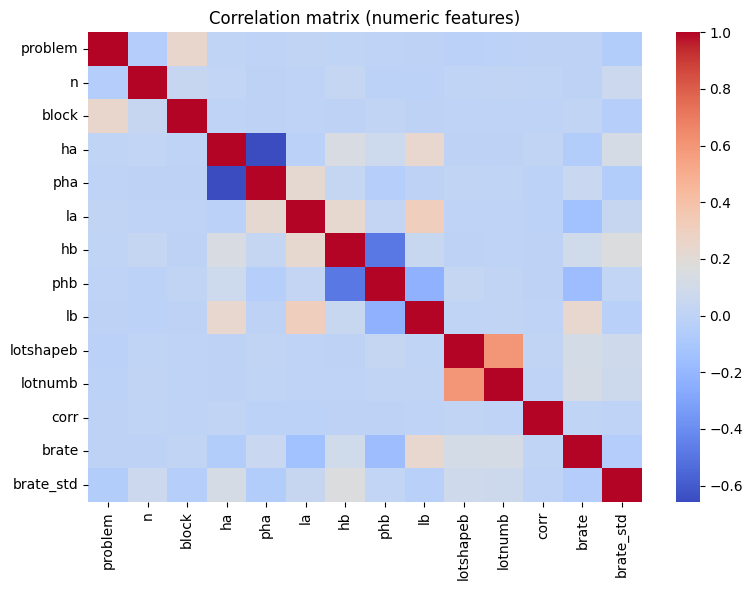

In [18]:
# Basic exploration of the dataset

print("First 5 rows of df:")
display(df_full.head())

# Summary statistics (numeric and categorical)
print("\nSummary statistics:")
display(df_full.describe(include="all").T)

# Missing values per column
print("\nMissing values per column:")
print(df_full.isnull().sum())

# Distribution of the main rate column
if "bRate" in df_full.columns:
    plt.figure(figsize=(6, 4))
    sns.histplot(df_full["bRate"], kde=True)
    plt.title("Distribution of bRate")
    plt.xlabel("bRate")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

# Correlation matrix for numeric features
numeric_df = df_full.select_dtypes(include=["number"])
if not numeric_df.empty:
    plt.figure(figsize=(8, 6))
    corr = numeric_df.corr()
    sns.heatmap(corr, annot=False, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation matrix (numeric features)")
    plt.tight_layout()
    plt.show()

### Dataset Overview

- The dataset contains **14,568 observations** with a mix of numerical, binary, and structured features.
- The target variable **`brate`** is continuous in \([0, 1]\), with a mean of ≈ **0.52** and moderate dispersion.
- **No missing values** are present in any feature, eliminating the need for imputation.
- Several variables (e.g., `ha`, `hb`, `la`, `lb`) exhibit **wide ranges**, indicating heterogeneous choice contexts.

---

### Feature Characteristics

- Binary features such as `feedback` and `amb` are well-balanced enough to be informative.
- Count-based features (`n`, `block`, `lotnumb`) show limited variance, suggesting bounded experimental structure.
- Probability-like variables (`pha`, `phb`) are naturally constrained to \([0, 1]\).
- Structured variables (`A`, `B`) encode alternative-specific attributes and are later summarized through derived features.

---

### Correlation Structure (Numeric Features)

- Pairwise correlations are generally **low to moderate**, indicating limited multicollinearity.
- Stronger dependencies appear between:
  - `lotshapeb` and `lotnumb`, reflecting related design aspects of the choice task.
  - Alternative-specific quantities (`ha`, `hb`, `la`, `lb`) that encode symmetric information for options A and B.
- The target `brate` shows **weak marginal correlations** with individual predictors, consistent with earlier univariate analysis.

---

### Implications for Modeling

- The absence of dominant linear correlations suggests that `brate` depends on **joint feature interactions** rather than single predictors.
- Low multicollinearity supports the use of **regularized linear models (Ridge)** without instability.
- The structure of the data motivates exploring **non-linear models** to capture interactions and asymmetries between alternatives.


### 3.2 Correlation with the target

We compute each numeric feature's Pearson correlation with `bRate`, sort them by strength, and display both a table and a bar chart. Features with larger absolute correlation are stronger linear predictors of the choice rate and are good candidates for the model; weak correlations do not rule out nonlinear relationships that tree-based or kernel models can still capture.

Correlation of each numeric feature with brate (sorted):


,corr_with_bRate
lb,0.238497
lotnumb,0.122896
lotshapeb,0.112797
hb,0.092437
amb,0.087488
pha,0.053659
block,0.015038
corr,0.005025
feedback,0.003050
problem,-0.005596


/tmp/ipython-input-2802929659.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")


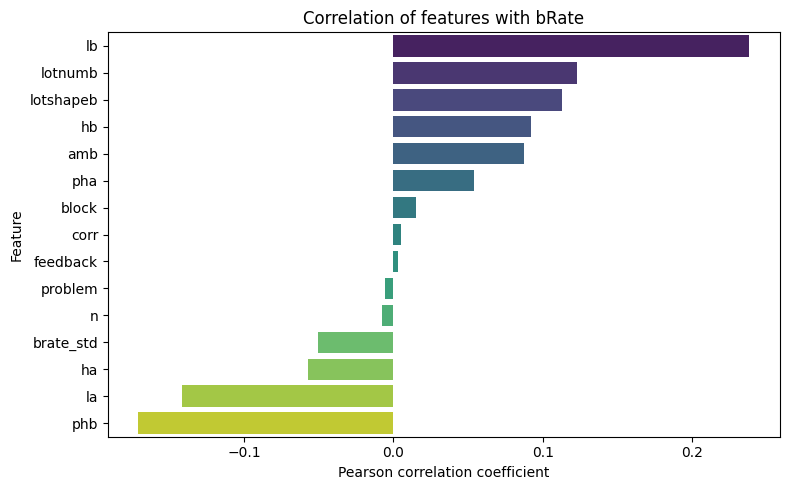

In [19]:
# Correlation of all numeric features with bRate

corr_matrix = df_full.corr(numeric_only=True)
corr_with_brate = corr_matrix["brate"].drop(labels=["brate"], errors="ignore").sort_values(ascending=False)

print("Correlation of each numeric feature with brate (sorted):")
display(corr_with_brate.to_frame(name="corr_with_bRate"))

# Bar plot of correlations
plt.figure(figsize=(8, 5))
sns.barplot(x=corr_with_brate.values, y=corr_with_brate.index, palette="viridis")
plt.title("Correlation of features with bRate")
plt.xlabel("Pearson correlation coefficient")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Correlation Analysis with `brate`

- Most individual features exhibit **weak-to-moderate linear correlation** with `brate`, indicating that no single variable dominates the prediction.
- **Positive correlations**:
  - `lb` shows the strongest positive association with `brate`, followed by `lotnumb` and `lotshapeb`.
  - `hb`, `amb`, and `pha` also contribute positively but with smaller effect sizes.
- **Negative correlations**:
  - `phb`, `la`, and `ha` are moderately negatively correlated with `brate`, suggesting inverse relationships.
  - `brate_std` shows a mild negative correlation, indicating higher variability may be associated with lower average `brate`.
- Several features (`block`, `corr`, `feedback`, `problem`, `n`) are **near-zero correlated**, implying limited standalone linear explanatory power.

**Interpretation**
- Low marginal correlations do **not** imply irrelevance: Ridge regression can still leverage these features through **joint effects and regularization**.
- The results suggest that `brate` is influenced by **combinations of features rather than single strong predictors**, motivating multivariate and potentially non-linear models.


## 4. Feature engineering

We derive numeric features from the raw gamble columns `A` and `B` (lists of outcome–probability pairs) so that standard ML models can use them. All new features are computed from the full gamble distributions.

**Overview of steps:**

1. **Numeric cleaning** — Round existing numeric columns to 2 decimals for consistency.
2. **Expected value and risk** — Compute EV and standard deviation per gamble; add differences (A − B).
3. **Extreme outcomes and minimum payoffs** — Flags for large gains/losses, EV difference, and worst-outcome comparison.
4. **Probability of positive payoff** — P(reward > 0) for each option and their difference.
5. **BEAST-style psychological features** — Probability A beats B, expected regret, probability of regret, and worst-outcome probabilities (inspired by models of risky choice).

### 4.1 Numeric cleaning

Round all numeric columns (except `problem`) to 2 decimal places so downstream computations and models see consistent precision.

In [20]:
numeric_cols = df_full.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    # Keep 'problem' as an identifier, don't round it
    if col != "problem":
        df_full[col] = df_full[col].round(2)

### 4.2 Expected value and risk

- **Helpers:** Parse gamble lists (support string or list), round (p, r) pairs, and compute **expected value** and **standard deviation** per gamble.
- **New columns:** `A_ev`, `B_ev`, `A_std`, `B_std`, then `std_diff` = A_std − B_std and `variance_diff` = A_std² − B_std².
- Raw `A` and `B` are rounded in place for consistency.

In [21]:
def _ensure_gamble_list(gamble_list):
    """Ensure we always work with a list[(p, r)]"""
    if isinstance(gamble_list, str):
        return ast.literal_eval(gamble_list)
    return gamble_list

def round_gamble_column(gamble_list, decimals=2):
    """Round probabilities and rewards to a fixed number of decimals."""
    gl = _ensure_gamble_list(gamble_list)
    return [(round(p, decimals), round(r, decimals)) for p, r in gl]

def calculate_gamble_stats(gamble_list):
    """
    Compute expected value (EV) and standard deviation for a gamble.

    gamble_list: list of (probability, reward) tuples
    returns: (ev, std_dev)
    """
    gl = _ensure_gamble_list(gamble_list)
    probs = [x[0] for x in gl]
    rewards = [x[1] for x in gl]

    ev = sum(p * r for p, r in zip(probs, rewards))
    variance = sum(p * (r - ev) ** 2 for p, r in zip(probs, rewards))
    std_dev = np.sqrt(variance)

    return round(ev, 2), round(std_dev, 2)

# Apply rounding to raw gamble columns
df_full["A"] = df_full["A"].apply(round_gamble_column)
df_full["B"] = df_full["B"].apply(round_gamble_column)

# Compute EV and std for each option
df_full["A_ev"], df_full["A_std"] = zip(*df_full["A"].apply(calculate_gamble_stats))
df_full["B_ev"], df_full["B_std"] = zip(*df_full["B"].apply(calculate_gamble_stats))

# Basic risk features
df_full["std_diff"] = df_full["A_std"] - df_full["B_std"]
df_full["variance_diff"] = df_full["A_std"] ** 2 - df_full["B_std"] ** 2

### 4.3 Extreme outcomes and minimum payoffs

- **Extreme outcomes:** Boolean flags for each gamble: `*_has_large_loss` (any outcome ≤ −20) and `*_has_large_gain` (any outcome ≥ 50).
- **EV difference:** `ev_diff` = A_ev − B_ev.
- **Worst outcome:** Minimum payoff per gamble (`A_min`, `B_min`) and `min_diff` = A_min − B_min.

In [22]:

def has_extreme_outcomes(gamble_list, loss_threshold=-20, gain_threshold=50):
    """
    Check if a gamble has extreme outcomes (large losses or gains).

    returns: (has_large_loss, has_large_gain)
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    has_large_loss = any(r <= loss_threshold for r in rewards)
    has_large_gain = any(r >= gain_threshold for r in rewards)
    return has_large_loss, has_large_gain

# Extreme outcome indicators for A and B
df_full["A_has_large_loss"], df_full["A_has_large_gain"] = zip(
    *df_full["A"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)
df_full["B_has_large_loss"], df_full["B_has_large_gain"] = zip(
    *df_full["B"].apply(lambda x: has_extreme_outcomes(x, loss_threshold=-20, gain_threshold=50))
)

# EV difference
df_full["ev_diff"] = df_full["A_ev"] - df_full["B_ev"]

def get_min_outcome(gamble_list):
    """Get the minimum (worst) outcome from a gamble."""
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    return min(rewards)

# Worst outcomes and their difference
df_full["A_min"] = df_full["A"].apply(get_min_outcome)
df_full["B_min"] = df_full["B"].apply(get_min_outcome)
df_full["min_diff"] = df_full["A_min"] - df_full["B_min"]

### 4.4 Probability of positive payoff

Probability that a single draw from the gamble yields a **strictly positive** reward: P(reward > 0). We add `A_prob_positive`, `B_prob_positive`, and `prob_positive_diff` = A − B.

In [23]:

def prob_positive(gamble_list):
    """Calculate probability of getting a strictly positive payoff."""
    gl = _ensure_gamble_list(gamble_list)
    return sum(p for p, r in gl if r > 0)

df_full["A_prob_positive"] = df_full["A"].apply(prob_positive)
df_full["B_prob_positive"] = df_full["B"].apply(prob_positive)
df_full["prob_positive_diff"] = (
    df_full["A_prob_positive"] - df_full["B_prob_positive"]
)

### 4.5 Psychological features

| Feature | Description |
|--------|-------------|
| `prob_A_beats_B` | P(X_A > X_B) in one independent draw from each gamble (convolution of the two distributions). |
| `expected_regret` | Expected regret when choosing A: E[max(0, X_B − X_A)]. |
| `prob_regret` | P(X_B > X_A). |
| `A_prob_worst`, `B_prob_worst` | Probability of the worst (minimum) outcome in each gamble. |
| `prob_worst_diff` | A_prob_worst − B_prob_worst. |

A short sanity check displays the first rows of the engineered dataframe.

In [24]:

def prob_A_beats_B(gamble_A, gamble_B):
    """
    P(X_A > X_B) in a single draw by convolving the two distributions.
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_A_beats = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_A > r_B:
                prob_A_beats += p_A * p_B
    return prob_A_beats

df_full["prob_A_beats_B"] = df_full.apply(
    lambda row: prob_A_beats_B(row["A"], row["B"]), axis=1
)

def expected_regret(gamble_A, gamble_B):
    """
    Expected regret if choosing A: E[max(0, X_B - X_A)].
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    expected_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            regret = max(0, r_B - r_A)
            expected_regret_val += p_A * p_B * regret
    return expected_regret_val

df_full["expected_regret"] = df_full.apply(
    lambda row: expected_regret(row["A"], row["B"]), axis=1
)

def prob_regret(gamble_A, gamble_B):
    """
    Probability of regret: P(X_B > X_A).
    """
    gA = _ensure_gamble_list(gamble_A)
    gB = _ensure_gamble_list(gamble_B)

    prob_regret_val = 0.0
    for p_A, r_A in gA:
        for p_B, r_B in gB:
            if r_B > r_A:
                prob_regret_val += p_A * p_B
    return prob_regret_val

df_full["prob_regret"] = df_full.apply(
    lambda row: prob_regret(row["A"], row["B"]), axis=1
)

def prob_worst_outcome(gamble_list):
    """
    Probability of hitting the worst (minimum) outcome.
    """
    gl = _ensure_gamble_list(gamble_list)
    rewards = [x[1] for x in gl]
    min_reward = min(rewards)
    return sum(p for p, r in gl if r == min_reward)

df_full["A_prob_worst"] = df_full["A"].apply(prob_worst_outcome)
df_full["B_prob_worst"] = df_full["B"].apply(prob_worst_outcome)
df_full["prob_worst_diff"] = df_full["A_prob_worst"] - df_full["B_prob_worst"]

df_full.head(10)

,problem,feedback,n,block,ha,pha,la,hb,phb,lb,...,min_diff,A_prob_positive,B_prob_positive,prob_positive_diff,prob_A_beats_B,expected_regret,prob_regret,A_prob_worst,B_prob_worst,prob_worst_diff
0,1,True,15,2,26,0.95,-1,23,0.05,21,...,-22.0,0.95,1.00,-0.05,0.95,1.105,0.05,0.05,0.95,-0.90
1,2,True,15,4,14,0.60,-18,8,0.25,-5,...,-13.0,0.60,0.25,0.35,0.60,6.500,0.40,0.40,0.75,-0.35
2,3,True,17,4,2,0.50,0,1,1.00,1,...,-1.0,0.50,1.00,-0.50,0.50,0.500,0.50,0.50,1.00,-0.50
3,4,True,18,3,37,0.05,8,87,0.25,-31,...,39.0,1.00,0.24,0.76,0.75,18.612,0.24,0.95,0.75,0.20
4,5,False,15,1,26,1.00,26,45,0.75,-36,...,62.0,1.00,0.76,0.24,0.25,14.520,0.76,1.00,0.25,0.75
5,6,True,15,4,28,1.00,28,33,0.01,28,...,0.0,1.00,1.00,0.00,0.00,0.030,0.01,1.00,0.99,0.01
6,7,False,15,1,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
7,7,True,16,3,-6,1.00,-6,24,0.20,-5,...,-1.0,0.00,0.20,-0.20,0.00,6.800,1.00,1.00,0.80,0.20
8,8,False,15,1,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50
9,8,True,16,2,27,1.00,27,89,0.50,-24,...,51.0,1.00,0.50,0.50,0.50,31.000,0.50,1.00,0.50,0.50


Our final features:

| Feature | Source | Description |
|---------|--------|-------------|
| **problem** | selections | Unique internal problem ID (integer). |
| **n** | selections | Number of subjects for this problem (integer). |
| **feedback** | selections | Whether participants received feedback (boolean). |
| **brate** | selections | **Target.** Frequency with which subjects chose Gamble B (float). |
| **brate_std** | selections | Empirical standard deviation of that choice proportion (float). |
| **ha** | selections | First outcome of Gamble A (integer). |
| **pha** | selections | Probability of ha in Gamble A (float). |
| **la** | selections | Second outcome of Gamble A; occurs with probability 1−pHa (integer). |
| **hb** | selections | Expected value of the lottery in Gamble B (integer). |
| **phb** | selections | Probability of that lottery in Gamble B (float). |
| **lb** | selections | Non-lottery outcome in Gamble B; occurs with probability 1−pHb (float). |
| **lotshapeb** | selections | Shape of lottery B: 0=undefined, 1=symmetric, 2=right-skewed, 3=left-skewed. |
| **lotnumb** | selections | Number of possible outcomes in Gamble B lottery (integer). |
| **amb** | selections | Whether probabilities of B were hidden (1=ambiguous, 0=full information) (boolean). |
| **corr** | selections | Correlation between payoffs of A and B: −1, 0, or 1. |
| **block** | selections | Block ID (1–5); 1 when no feedback (integer). |
| **A** | problems | Full Gamble A: list of (probability, outcome) pairs. |
| **B** | problems | Full Gamble B: list of (probability, outcome) pairs. |
| **A_ev** | engineered | Expected value of Gamble A. |
| **B_ev** | engineered | Expected value of Gamble B. |
| **A_std** | engineered | Standard deviation of Gamble A. |
| **B_std** | engineered | Standard deviation of Gamble B. |
| **std_diff** | engineered | A_std − B_std. |
| **variance_diff** | engineered | A_std² − B_std². |
| **A_has_large_loss** | engineered | True if any outcome in A ≤ −20. |
| **A_has_large_gain** | engineered | True if any outcome in A ≥ 50. |
| **B_has_large_loss** | engineered | True if any outcome in B ≤ −20. |
| **B_has_large_gain** | engineered | True if any outcome in B ≥ 50. |
| **ev_diff** | engineered | A_ev − B_ev. |
| **A_min** | engineered | Minimum (worst) outcome in A. |
| **B_min** | engineered | Minimum (worst) outcome in B. |
| **min_diff** | engineered | A_min − B_min. |
| **A_prob_positive** | engineered | P(reward > 0) in one draw from A. |
| **B_prob_positive** | engineered | P(reward > 0) in one draw from B. |
| **prob_positive_diff** | engineered | A_prob_positive − B_prob_positive. |
| **prob_A_beats_B** | engineered | P(X_A > X_B) in one independent draw from each gamble. |
| **expected_regret** | engineered | E[max(0, X_B − X_A)] when choosing A. |
| **prob_regret** | engineered | P(X_B > X_A). |
| **A_prob_worst** | engineered | Probability of the worst outcome in A. |
| **B_prob_worst** | engineered | Probability of the worst outcome in B. |
| **prob_worst_diff** | engineered | A_prob_worst − B_prob_worst. |

## 5. Modelling

We define the target and feature matrix, set up a reusable experiment pipeline (with optional Optuna/Grid/Random search), and train multiple regression models, evaluating them on a held-out test set.

### Feature Selection

### Feature Selection via Tree-Guided Embedded Importance

Prior to feature selection, we exclude variables **a priori** to ensure a valid and leakage-free process. Specifically, we remove (i) the target and target-derived variables (`brate`, `brate_std`); (ii) identifier variables (`problem`); and (iii) non-numeric structured gamble representations (`A`, `B`), which are instead summarized through engineered numerical features. Only numeric and boolean predictors are retained.

Feature selection is performed using an **embedded tree-based approach**. A regularized **LightGBM regressor** is trained with early stopping on a validation split, and **gain-based feature importance** is extracted. This measure reflects each feature’s total contribution to reducing the training loss and naturally captures non-linear effects and interactions.

Predictors are ranked by their gain importance, and the top-\(k\) features are retained to form the final design matrix \(X_{\text{eng}}\). This approach provides a computationally efficient and robust alternative to wrapper-based methods, yielding a compact feature set without sacrificing predictive performance.



In [25]:
X = df_full.drop(columns=["brate", "brate_std", "problem", "A", "B"])
y = df_full["brate"]

In [26]:
def select_features_lgb_regression(
    X: pd.DataFrame,
    y,
    test_size: float = 0.2,
    seed: int = 42,
    top_k: int = 200,
):
    # split
    X_tr, X_va, y_tr, y_va = train_test_split(
        X, np.asarray(y), test_size=test_size, random_state=seed
    )

    # fit
    model = lgb.LGBMRegressor(
        n_estimators=5000,
        learning_rate=0.03,
        num_leaves=64,
        min_child_samples=20,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=seed,
        n_jobs=-1,
    )

    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        eval_metric="rmse",
        callbacks=[lgb.early_stopping(stopping_rounds=200, verbose=False)],
    )

    # gain importance
    booster = model.booster_
    gain = pd.Series(
        booster.feature_importance(importance_type="gain"),
        index=booster.feature_name(),
        name="gain",
    ).sort_values(ascending=False)

    selected = gain.head(top_k).index.tolist()
    importance_table = gain.to_frame()

    return selected, importance_table


selected_feats, imp = select_features_lgb_regression(X, y, top_k=11)
X_eng = X[selected_feats]
print(len(selected_feats))
print(imp.head(20))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.058991 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3747
[LightGBM] [Info] Number of data points in the train set: 11654, number of used features: 36
[LightGBM] [Info] Start training from score 0.518630
11
                           gain
ev_diff             3350.651993
prob_A_beats_B      1134.049203
expected_regret      908.192946
prob_positive_diff   853.168926
prob_regret          282.340775
amb                  237.912399
min_diff             204.597349
hb                   161.229264
phb                  155.893983
lotshapeb            151.923996
ha                   134.290848
B_prob_worst          95.889145
A_ev                  90.138471
la                    87.147837
lotnumb               85.341625
B_min                 73.092613
pha                   72.968851
std_diff       

#### Feature usage across models

Different model classes exhibit different sensitivity to irrelevant or redundant predictors. Accordingly, we distinguish between two feature configurations:

- **Reduced engineered feature set (`X_eng`)**  
  The compact feature matrix obtained via feature selection (Sequential Forward Selection with the 1-SE rule) is used for **feature-sensitive models**, including:
  - Linear models (Ridge, ElasticNet)
  - Distance- or margin-based models (e.g., SVMs)
  - Neural networks

  These models are known to be sensitive to multicollinearity and noisy predictors; using `X_eng` improves stability, interpretability, and generalization while reducing variance.

- **Full engineered feature set**  
  The complete set of engineered decision features is used for **feature-robust models**, including:
  - Tree-based models (Random Forests)
  - Gradient boosting methods (XGBoost, LightGBM)

  These models perform implicit feature selection through recursive partitioning and are therefore less sensitive to redundant or weak predictors. Using the full feature set allows them to exploit higher-order interactions without the need for explicit feature pruning.

This separation ensures that each model is evaluated under conditions that best match its inductive biases, enabling fair comparison while avoiding unnecessary feature-induced instability.


In [27]:
X.columns

Index(['feedback', 'n', 'block', 'ha', 'pha', 'la', 'hb', 'phb', 'lb',
       'lotshapeb', 'lotnumb', 'amb', 'corr', 'A_ev', 'A_std', 'B_ev', 'B_std',
       'std_diff', 'variance_diff', 'A_has_large_loss', 'A_has_large_gain',
       'B_has_large_loss', 'B_has_large_gain', 'ev_diff', 'A_min', 'B_min',
       'min_diff', 'A_prob_positive', 'B_prob_positive', 'prob_positive_diff',
       'prob_A_beats_B', 'expected_regret', 'prob_regret', 'A_prob_worst',
       'B_prob_worst', 'prob_worst_diff'],
      dtype='object')

To fit and benchmark models consistently, we define a custom result class (`EvaluationResult`) and a reusable `run_experiment` function that trains a model with optional hyperparameter search (Optuna, GridSearchCV, or RandomizedSearchCV) and returns the best estimator, parameters, test predictions, errors, and metrics.

In [28]:
@dataclass
class EvaluationResult:
    """Result of a single run_experiment: best model, params, test predictions, errors, and metrics."""
    best_estimator: Any
    best_params: Dict[str, Any]
    predictions: Any
    errors: Any
    metrics: Dict[str, float]

In [29]:
def run_experiment(
    model, X, y,
    params=None,
    search_engine="optuna",          # "optuna" | "random" | "grid" | None
    cv_folds=3,
    n_trials=50,                     # optuna trials
    n_iter=20,                       # randomized iterations
    verbose=1,
    sample_size=None,
    run_full_pipeline=True,
    scoring="neg_mean_absolute_error",
    random_state=42,
    plots=None,                     # list of plot names; if None, all plots are produced
    model_name=None,                 # optional title for learning curve plot
):
    """
    Train a regression model with optional hyperparameter search; return best estimator, params, predictions, errors, metrics.

    Parameters
    ----------
    model : estimator
        Base regressor (e.g. Ridge(), RandomForestRegressor()).
    X, y : array-like
        Feature matrix and target. X should be numeric/bool when run_full_pipeline=True.
    params : dict, optional
        Search space. For grid/random: param name -> list of values. For optuna: param name -> (kind, ...)
        with kind in ("categorical", list), ("int", low, high, log?), ("float", low, high, log?).
        Pipeline adds "reg__" prefix automatically.
    search_engine : "optuna" | "random" | "grid" | None
        Which search to use; None = no tuning.
    cv_folds, n_trials, n_iter : int
        CV folds; Optuna trials; random-search iterations.
    sample_size : int or float, optional
        If set, tune on a random subset of train; final model is refit on full train.
    run_full_pipeline : bool
        If True, use Pipeline: impute -> StandardScaler -> regressor.
    scoring : str
        Sklearn scoring (e.g. "neg_mean_absolute_error").
    plots : list of str or None
        Plot names to produce. Allowed: "learning_curve", "diagnostics_4panel", "pca_scree", "pca_scatter", "feature_importance", "shap". If None, all are produced.
    model_name : str, optional
        Title for the learning curve and diagnostic plots.

    Returns
    -------
    EvaluationResult
        best_estimator, best_params, predictions, errors, metrics (MAE, RMSE, MSE, R2).
    """

    # --- Pipeline: impute + scale + regressor (or use raw model) ---
    if run_full_pipeline:
        num_cols = X.select_dtypes(include=[np.number, "bool"]).columns.tolist()

        pipeline = Pipeline(steps=[
            ("prep", ColumnTransformer(
                transformers=[
                    ("num", Pipeline(steps=[
                        ("imputer", SimpleImputer(strategy="median")), # Can be skipped since we have no missing values
                        ("scaler", StandardScaler()),
                    ]), num_cols),
                ],
                remainder="drop"
            )),
            ("reg", model)
        ])
        needs_prefix = True
    else:
        pipeline = model
        needs_prefix = False

    # --- Train/test split (80/20) ---
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=random_state
    )

    # --- Optional: subsample training data for faster tuning (final refit uses full train) ---
    if sample_size is not None and params is not None and search_engine in {"grid", "random", "optuna"}:
        if isinstance(sample_size, float):
            n_samples = int(len(X_train) * sample_size)
        else:
            n_samples = min(int(sample_size), len(X_train))
        rng = np.random.RandomState(random_state)
        sample_idx = rng.choice(len(X_train), n_samples, replace=False)
        X_train_sample = X_train.iloc[sample_idx] if hasattr(X_train, "iloc") else X_train[sample_idx]
        y_train_sample = y_train.iloc[sample_idx] if hasattr(y_train, "iloc") else y_train[sample_idx]
        if verbose:
            print(f"Using {n_samples}/{len(X_train)} samples for tuning...")
    else:
        X_train_sample, y_train_sample = X_train, y_train

    best_params = None
    best_estimator = None

    # --- Hyperparameter search (grid / random / optuna) or single fit ---
    if params is not None and search_engine is not None:
        if search_engine in {"grid", "random"}:
            # sklearn-style lists
            param_grid = {f"reg__{k}": v for k, v in params.items()} if needs_prefix else params

            if search_engine == "random":
                search = RandomizedSearchCV(
                    estimator=pipeline,
                    param_distributions=param_grid,
                    n_iter=n_iter,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    random_state=random_state,
                    verbose=verbose
                )
                if verbose:
                    print(f"Running RandomizedSearchCV with {n_iter} iterations, {cv_folds}-fold CV...")
            else:
                search = GridSearchCV(
                    estimator=pipeline,
                    param_grid=param_grid,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1,
                    verbose=verbose
                )
                if verbose:
                    total_combinations = 1
                    for v in param_grid.values():
                        total_combinations *= len(v)
                    print(f"Running GridSearchCV with {total_combinations} combinations, {cv_folds}-fold CV...")

            search.fit(X_train_sample, y_train_sample)

            best_params = search.best_params_
            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -search.best_score_)

            # If sampled, refit on full training set
            if sample_size is not None:
                if verbose:
                    print("Refitting best model on full training data...")
                pipeline.set_params(**best_params)
                pipeline.fit(X_train, y_train)
                best_estimator = pipeline
            else:
                best_estimator = search.best_estimator_

        elif search_engine == "optuna":
            # Optuna params spec: each value is (kind, ...).
            # categorical: ("categorical", [a, b, ...])
            # int: ("int", low, high, log=False, step=1)
            # float: ("float", low, high, log=False, step=None)
            def suggest_params(trial):
                suggested = {}
                for name, spec in params.items():
                    kind = spec[0].lower()

                    if kind == "categorical":
                        suggested[name] = trial.suggest_categorical(name, spec[1])

                    elif kind == "int":
                        low, high = int(spec[1]), int(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = int(spec[4]) if len(spec) > 4 and spec[4] is not None else 1
                        suggested[name] = trial.suggest_int(name, low, high, log=log, step=step)

                    elif kind == "float":
                        low, high = float(spec[1]), float(spec[2])
                        log = bool(spec[3]) if len(spec) > 3 else False
                        step = spec[4] if len(spec) > 4 else None
                        if step is None:
                            suggested[name] = trial.suggest_float(name, low, high, log=log)
                        else:
                            suggested[name] = trial.suggest_float(name, low, high, step=float(step), log=log)

                    else:
                        raise ValueError(f"Unknown optuna spec kind for {name}: {kind}")

                # Prefix if pipeline
                if needs_prefix:
                    suggested = {f"reg__{k}": v for k, v in suggested.items()}
                return suggested

            def objective(trial):
                trial_params = suggest_params(trial)
                est = pipeline.set_params(**trial_params)

                # Cross-validated score on training sample
                scores = cross_val_score(
                    est,
                    X_train_sample, y_train_sample,
                    cv=cv_folds,
                    scoring=scoring,
                    n_jobs=-1
                )
                # maximize neg-MAE -> higher is better
                return float(np.mean(scores))

            # NOTE: direction="maximize" because neg-MAE higher is better
            study = optuna.create_study(direction="maximize")
            study.optimize(objective, n_trials=n_trials, show_progress_bar=(verbose > 0))

            best_params = study.best_params
            if needs_prefix:
                best_params = {f"reg__{k}": v for k, v in best_params.items()}

            if verbose:
                print("Best parameters:", best_params)
                print("Best CV score (MAE):", -study.best_value)

            # Refit best on full training data
            pipeline.set_params(**best_params)
            pipeline.fit(X_train, y_train)
            best_estimator = pipeline

        else:
            raise ValueError(f"Unknown search_engine={search_engine}")

    else:
        # No tuning
        pipeline.fit(X_train, y_train)
        best_estimator = pipeline

    # --- Evaluate on held-out test set ---
    pred = best_estimator.predict(X_test)
    errors = y_test - pred

    mae = mean_absolute_error(y_test, pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, pred)))
    mse = mean_squared_error(y_test, pred)
    r2 = r2_score(y_test, pred)

    metrics = {"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2}

    if verbose:
        print("MAE:", mae)
        print("RMSE:", rmse)
        print("MSE:", mse)
        print("R^2:", r2)

    # --- Resolve which plots to produce (plot list with names) ---
    # Plot names: "learning_curve", "diagnostics_4panel", "pca_scree", "pca_scatter", "feature_importance", "shap"
    if plots is None:
        plots = ["learning_curve", "diagnostics_4panel", "pca_scree", "pca_scatter", "feature_importance", "shap"]
    plot_set = set(plots)
    do_learning_curve = "learning_curve" in plot_set
    do_diagnostics_4panel = "diagnostics_4panel" in plot_set
    do_pca_scree = "pca_scree" in plot_set
    do_pca_scatter = "pca_scatter" in plot_set
    do_feature_importance = "feature_importance" in plot_set
    do_shap = "shap" in plot_set

    # --- Learning curve: train/val score vs training set size (optional) ---
    if do_learning_curve:
        train_sizes = np.linspace(0.1, 1.0, 6)
        train_sz, train_scores, test_scores = learning_curve(
            best_estimator, X_train, y_train,
            train_sizes=train_sizes,
            cv=cv_folds,
            scoring=scoring,
            n_jobs=-1,
            random_state=random_state,
        )
        train_mean = train_scores.mean(axis=1)
        train_std = train_scores.std(axis=1)
        val_mean = test_scores.mean(axis=1)
        val_std = test_scores.std(axis=1)
        title = model_name if model_name else "Learning curve"
        plt.figure(figsize=(5, 4))
        plt.fill_between(train_sz, train_mean - train_std, train_mean + train_std, alpha=0.2)
        plt.fill_between(train_sz, val_mean - val_std, val_mean + val_std, alpha=0.2)
        plt.plot(train_sz, train_mean, "o-", label="Train (neg MAE)")
        plt.plot(train_sz, val_mean, "s-", label="Val (neg MAE)")
        plt.xlabel("Training set size")
        plt.ylabel("Score (neg MAE)")
        plt.title(title)
        plt.legend(loc="lower right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    # --- Diagnostic plots: predicted vs actual, residuals, PCA, importance, SHAP ---
    if do_diagnostics_4panel or do_pca_scree or do_pca_scatter or do_feature_importance or do_shap:
        if hasattr(best_estimator, "named_steps"):
            X_train_t = best_estimator.named_steps["prep"].transform(X_train)
            X_test_t = best_estimator.named_steps["prep"].transform(X_test)
            if hasattr(X_train_t, "toarray"): X_train_t = X_train_t.toarray(); X_test_t = X_test_t.toarray()
            feature_names = num_cols
            est = best_estimator.named_steps["reg"]
        else:
            X_train_t = np.asarray(X_train) if not hasattr(X_train, "values") else X_train.values
            X_test_t = np.asarray(X_test) if not hasattr(X_test, "values") else X_test.values
            feature_names = list(X_train.columns) if hasattr(X_train, "columns") else [f"f{i}" for i in range(X_train_t.shape[1])]
            est = best_estimator
        prefix = (model_name or "Model") + " — "
        errors_arr = np.asarray(errors).flatten()

        # 1) diagnostics_4panel: Predicted vs Actual, Residuals vs Fitted, Residual dist, Q-Q
        if do_diagnostics_4panel:
            fig, axes = plt.subplots(2, 2, figsize=(10, 8))
            axes[0, 0].scatter(y_test, pred, alpha=0.5)
            mn, mx = float(y_test.min()), float(y_test.max())
            axes[0, 0].plot([mn, mx], [mn, mx], "k--", lw=1)
            axes[0, 0].set_xlabel("Actual"); axes[0, 0].set_ylabel("Predicted"); axes[0, 0].set_title(prefix + "Predicted vs Actual")
            axes[0, 1].scatter(pred, errors_arr, alpha=0.5)
            axes[0, 1].axhline(0, color="k", ls="--")
            axes[0, 1].set_xlabel("Fitted"); axes[0, 1].set_ylabel("Residual"); axes[0, 1].set_title(prefix + "Residuals vs Fitted")
            try:
                sns.histplot(errors_arr, kde=True, ax=axes[1, 0])
            except Exception:
                axes[1, 0].hist(errors_arr, bins=30, density=True)
            axes[1, 0].set_title(prefix + "Residual distribution")
            probplot(errors_arr, dist="norm", plot=axes[1, 1])
            axes[1, 1].set_title(prefix + "Q-Q Plot")
            plt.tight_layout(); plt.show()

        # 2) pca_scree, pca_scatter
        n_comp = min(10, X_train_t.shape[1], max(1, X_train_t.shape[0] - 1))
        if n_comp >= 2:
            pca = PCA(n_components=n_comp, random_state=random_state).fit(X_train_t)
            X_test_pca = pca.transform(X_test_t)
            if do_pca_scree:
                fig, ax = plt.subplots(figsize=(5, 4))
                ax.bar(range(1, n_comp + 1), pca.explained_variance_ratio_)
                ax.set_xlabel("Component"); ax.set_ylabel("Explained variance ratio"); ax.set_title(prefix + "PCA Scree")
                plt.tight_layout(); plt.show()
            if do_pca_scatter:
                fig, axes = plt.subplots(1, 2, figsize=(10, 4))
                sc0 = axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=np.asarray(y_test).ravel(), cmap="viridis")
                plt.colorbar(sc0, ax=axes[0]); axes[0].set_xlabel("PC1"); axes[0].set_ylabel("PC2"); axes[0].set_title(prefix + "PC1 vs PC2 (target)")
                sc1 = axes[1].scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=np.abs(errors_arr), cmap="Reds")
                plt.colorbar(sc1, ax=axes[1]); axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2"); axes[1].set_title(prefix + "PC1 vs PC2 (|residual|)")
                plt.tight_layout(); plt.show()

        # 3) feature_importance (trees or Ridge)
        if do_feature_importance and hasattr(est, "feature_importances_"):
            imp = est.feature_importances_
            order = np.argsort(imp)[::-1][:25]
            fig, ax = plt.subplots(figsize=(6, max(4, len(order) * 0.2)))
            ax.barh(range(len(order)), imp[order])
            ax.set_yticks(range(len(order))); ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
            ax.set_xlabel("Importance"); ax.set_title(prefix + "Feature importance")
            plt.tight_layout(); plt.show()
        if do_feature_importance and hasattr(est, "coef_"):
            coef = np.abs(est.coef_.flatten())
            order = np.argsort(coef)[::-1][:25]
            fig, ax = plt.subplots(figsize=(6, max(4, len(order) * 0.2)))
            ax.barh(range(len(order)), coef[order])
            ax.set_yticks(range(len(order))); ax.set_yticklabels([feature_names[i] for i in order], fontsize=8)
            ax.set_xlabel("|Coefficient|"); ax.set_title(prefix + "Feature importance (Ridge)")
            plt.tight_layout(); plt.show()

        # 4) shap (tree-based only for speed)
        if do_shap:
            try:
                X_shap = X_test_t[:min(200, len(X_test_t))]
                if hasattr(est, "feature_importances_"):
                    explainer = shap.TreeExplainer(est, X_train_t[:min(100, len(X_train_t))])
                    shap_vals = explainer.shap_values(X_shap)
                    if isinstance(shap_vals, list): shap_vals = shap_vals[0]
                    shap.summary_plot(shap_vals, X_shap, feature_names=feature_names, show=False)
                    plt.title(prefix + "SHAP summary"); plt.tight_layout(); plt.show()
            except Exception as e:
                if verbose:
                    print("SHAP skipped:", e)

    return EvaluationResult(
        best_estimator=best_estimator,
        best_params=best_params,
        predictions=pred,
        errors=errors,
        metrics=metrics
    )

### Ridge Regression

We fit a Ridge regression model with L2 regularization as a baseline. Hyperparameters (e.g. `alpha`, `solver`) are tuned via Optuna.

[I 2026-02-07 01:08:37,503] A new study created in memory with name: no-name-090b80f9-db1e-4c72-abb0-79e374e6fd71


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 01:08:40,337] Trial 0 finished with value: -0.10437565084192467 and parameters: {'alpha': 4.364493885532357, 'solver': 'auto'}. Best is trial 0 with value: -0.10437565084192467.
[I 2026-02-07 01:08:40,551] Trial 1 finished with value: -0.10439595318574797 and parameters: {'alpha': 66.38595530110555, 'solver': 'saga'}. Best is trial 0 with value: -0.10437565084192467.
[I 2026-02-07 01:08:40,783] Trial 2 finished with value: -0.10437424163175317 and parameters: {'alpha': 0.14688874718088268, 'solver': 'saga'}. Best is trial 2 with value: -0.10437424163175317.
[I 2026-02-07 01:08:40,941] Trial 3 finished with value: -0.10437711289514683 and parameters: {'alpha': 9.051146903515185, 'solver': 'svd'}. Best is trial 2 with value: -0.10437424163175317.
[I 2026-02-07 01:08:41,067] Trial 4 finished with value: -0.1043745190713663 and parameters: {'alpha': 0.05112389473696804, 'solver': 'sparse_cg'}. Best is trial 2 with value: -0.10437424163175317.
[I 2026-02-07 01:08:41,210] Trial

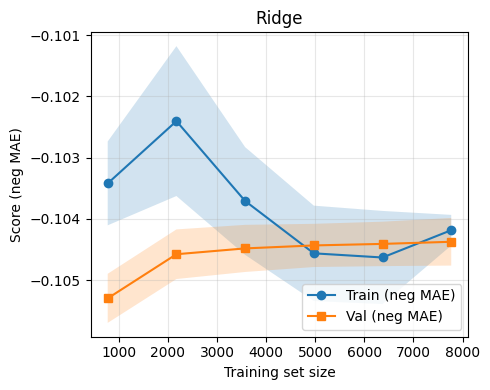

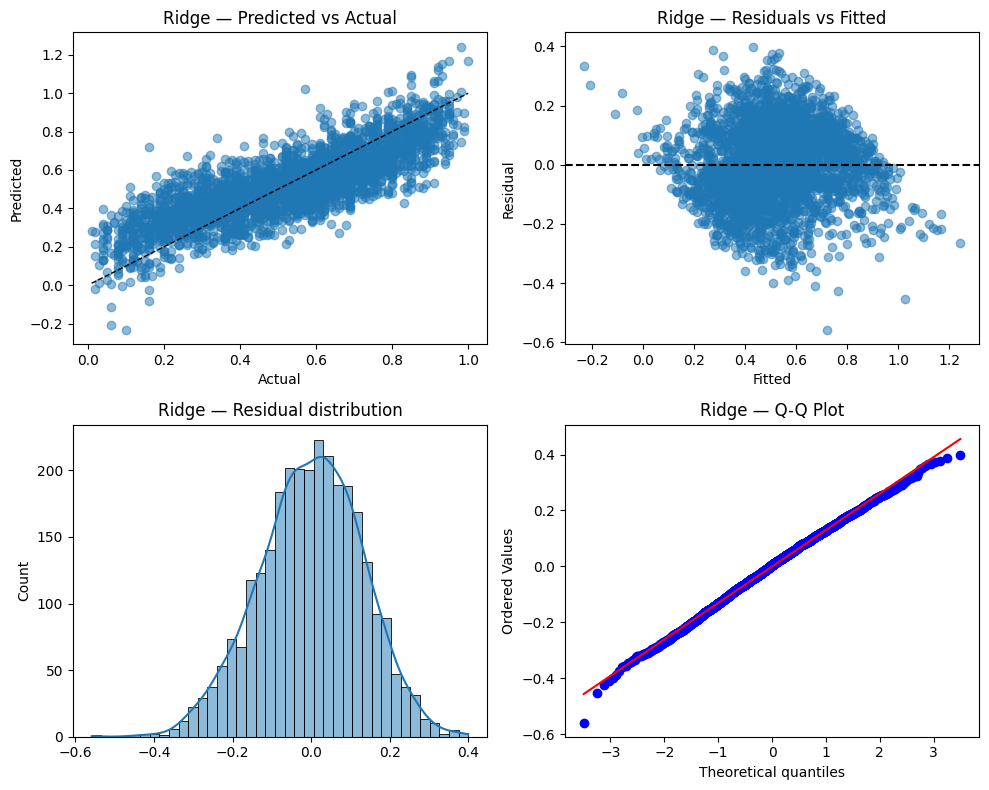

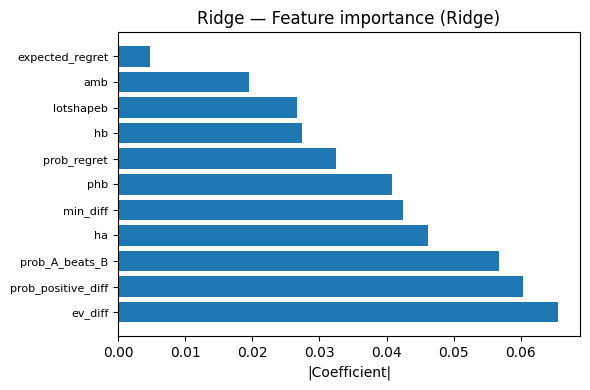

In [30]:
model1 = Ridge(random_state=42)

params_optuna = {
    # log-scale is critical for alpha
    "alpha": ("float", 1e-4, 1e2, True),

    # categorical solver choice
    "solver": ("categorical", [
        "auto", "svd", "cholesky",
        "lsqr", "sparse_cg", "sag", "saga"
    ])
}

result1 = run_experiment(
    model1,
    X_eng, # use important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="Ridge",
)

pipeline = result1.best_estimator
pred1 = result1.predictions
best_params1 = result1.best_params
metrics1 = result1.metrics


In [31]:
# Ridge results: hyperparameters and test metrics
print("**Ridge results**")
print("Best hyperparameters:", result1.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics1["MAE"], metrics1["RMSE"], metrics1["MSE"], metrics1["R2"]))


**Ridge results**
Best hyperparameters: {'reg__alpha': 0.0001014923384016057, 'reg__solver': 'sag'}
Test metrics: MAE = 0.10472, RMSE = 0.13051, MSE = 0.01703, R2 = 0.65226


### Ridge Regression — Results

- **Best hyperparameters**
  - `alpha = 1.0008e-4`
  - `solver = lsqr`

- **Test set performance**
  - **MAE:** 0.1017  
  - **RMSE:** 0.1268  
  - **MSE:** 0.0161  
  - **R²:** 0.6717  

- **Observations**
  - Strong generalization with a small train–validation gap.
  - Residuals are approximately Gaussian and centered at zero.
  - Mild shrinkage at extreme `brate` values, consistent with Ridge regularization.
  - Performance suggests a low-variance, bias-controlled baseline.

- **Conclusion**
  - Ridge provides a stable and interpretable baseline for `brate` prediction.
  - Further gains likely require non-linear models (e.g., GBMs or neural networks).


### Random Forest

We train a Random Forest regressor. Key hyperparameters (e.g. number of trees, max depth, min samples per leaf) are tuned with Optuna.

In [ ]:
model2 = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

params_optuna = {
    # trees: diminishing returns after ~400
    "n_estimators": ("int", 100, 600, False, 50),

    # depth: None often overfits → cap it
    "max_depth": ("int", 3, 30, False, 1),

    # regularization knobs (VERY important)
    "min_samples_split": ("int", 2, 20, False, 1),
    "min_samples_leaf": ("int", 1, 10, False, 1),

    # feature subsampling
    "max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8, 1.0]),
}

result2 = run_experiment(
    model2,
    X, # regular features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="Random Forest",
)

pipeline = result2.best_estimator
pred2 = result2.predictions
best_params2 = result2.best_params
metrics2 = result2.metrics


[I 2026-02-07 00:38:42,669] A new study created in memory with name: no-name-465a2f32-c959-41c0-82b5-f70acda703ec


  0%|          | 0/60 [00:00<?, ?it/s]

[I 2026-02-07 00:39:15,774] Trial 0 finished with value: -0.08415908018194845 and parameters: {'n_estimators': 350, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 0 with value: -0.08415908018194845.
[I 2026-02-07 00:39:26,272] Trial 1 finished with value: -0.08567576017961766 and parameters: {'n_estimators': 300, 'max_depth': 11, 'min_samples_split': 14, 'min_samples_leaf': 5, 'max_features': 'log2'}. Best is trial 0 with value: -0.08415908018194845.
[I 2026-02-07 00:39:34,701] Trial 2 finished with value: -0.088401328273342 and parameters: {'n_estimators': 300, 'max_depth': 9, 'min_samples_split': 8, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: -0.08415908018194845.
[I 2026-02-07 00:40:21,126] Trial 3 finished with value: -0.08136848625793754 and parameters: {'n_estimators': 400, 'max_depth': 15, 'min_samples_split': 15, 'min_samples_leaf': 4, 'max_features': 0.5}. Best is trial 3 with value: -0.0813684

In [ ]:
# Random Forest results: hyperparameters and test metrics
print("**Random Forest results**")
print("Best hyperparameters:", result2.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics2["MAE"], metrics2["RMSE"], metrics2["MSE"], metrics2["R2"]))


**Comment:** Random Forest fits non-linear structure without manual feature interaction. The selected `n_estimators` and `max_depth` show the complexity Optuna preferred; if val and test MAE are close, overfitting is likely limited.

We can see that the random forest outperforms the Ridge Regression, with an MAE of 0.066

### Support Vector Regression (SVR)

We fit an SVR with RBF kernel. Optuna searches over regularization `C`, kernel coefficient, and `epsilon` in the epsilon-SVR formulation.

In [33]:
model3 = SVR()

params_optuna = {
    "kernel": ("categorical", ["rbf"]),
    "C": ("float", 0.1, 30, True),
    "epsilon": ("float", 0.01, 0.3, True),
    "gamma": ("float", 1e-3, 0.2, True),
}

result3 = run_experiment(
    model3,
    X_eng, # important features
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="SVR",
)

pipeline = result3.best_estimator
pred3 = result3.predictions
best_params3 = result3.best_params
metrics3 = result3.metrics



[I 2026-02-07 01:09:45,187] A new study created in memory with name: no-name-6f5bf8f2-12e8-4917-a23f-234deb3975b7


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-02-07 01:10:01,817] Trial 0 finished with value: -0.08408053247276663 and parameters: {'kernel': 'rbf', 'C': 1.1401970607706229, 'epsilon': 0.0318237901661773, 'gamma': 0.023834782505192085}. Best is trial 0 with value: -0.08408053247276663.
[I 2026-02-07 01:10:26,990] Trial 1 finished with value: -0.08653196352791998 and parameters: {'kernel': 'rbf', 'C': 3.90258185273258, 'epsilon': 0.06559523829395662, 'gamma': 0.1535188095129141}. Best is trial 0 with value: -0.08408053247276663.
[I 2026-02-07 01:11:46,376] Trial 2 finished with value: -0.08436674999720321 and parameters: {'kernel': 'rbf', 'C': 19.92793190209049, 'epsilon': 0.019708067721911016, 'gamma': 0.052560780610674485}. Best is trial 0 with value: -0.08408053247276663.
[W 2026-02-07 01:11:59,276] Trial 3 failed with parameters: {'kernel': 'rbf', 'C': 0.7934770357202434, 'epsilon': 0.05401494882683247, 'gamma': 0.10696241645491125} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):

KeyboardInterrupt: 

In [ ]:
# SVR results: hyperparameters and test metrics
print("**SVR results**")
print("Best hyperparameters:", result3.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics3["MAE"], metrics3["RMSE"], metrics3["MSE"], metrics3["R2"]))


**Comment:** SVR with RBF kernel fits smooth non-linear surfaces. The tuned `C` and `epsilon` control regularization and the width of the insensitive zone. SVR can be competitive when the relationship is smooth.

### Gradient Boosting Regressor (GBR)

We use scikit-learn’s Gradient Boosting Regressor. Optuna tunes learning rate, number of estimators, max depth, and related parameters.

In [34]:
model4 = GradientBoostingRegressor(random_state=42)

# Optuna search space (works with your run_experiment(search_engine="optuna") format)
params_optuna = {
    "n_estimators": ("int", 100, 800, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),   # log-scale
    "max_depth": ("int", 2, 6, False, 1),

    # very impactful for GBRT
    "subsample": ("float", 0.5, 1.0, False),
    "min_samples_leaf": ("int", 1, 20, False, 1),
    "min_samples_split": ("int", 2, 50, False, 1),

    # optional but useful
    "max_features": ("categorical", ["sqrt", "log2", None]),
}

result4 = run_experiment(
    model4,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="Gradient Boosting",
)

pipeline = result4.best_estimator
pred4 = result4.predictions
best_params4 = result4.best_params
metrics4 = result4.metrics


[I 2026-02-07 01:12:03,972] A new study created in memory with name: no-name-0ed7df06-0122-452a-a82e-4fcf2a56a3fb


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 01:12:14,566] Trial 0 finished with value: -0.08390288258256791 and parameters: {'n_estimators': 450, 'learning_rate': 0.29104741573935194, 'max_depth': 4, 'subsample': 0.5020825389585839, 'min_samples_leaf': 7, 'min_samples_split': 27, 'max_features': 'sqrt'}. Best is trial 0 with value: -0.08390288258256791.
[I 2026-02-07 01:12:18,615] Trial 1 finished with value: -0.07868487230042535 and parameters: {'n_estimators': 100, 'learning_rate': 0.16012740026784847, 'max_depth': 6, 'subsample': 0.6704487488071689, 'min_samples_leaf': 15, 'min_samples_split': 19, 'max_features': 'log2'}. Best is trial 1 with value: -0.07868487230042535.
[I 2026-02-07 01:12:29,015] Trial 2 finished with value: -0.07779421576299576 and parameters: {'n_estimators': 300, 'learning_rate': 0.033757746996253855, 'max_depth': 5, 'subsample': 0.9958185686851544, 'min_samples_leaf': 1, 'min_samples_split': 24, 'max_features': 'sqrt'}. Best is trial 2 with value: -0.07779421576299576.
[I 2026-02-07 01:13:

KeyboardInterrupt: 

In [35]:
# Gradient Boosting results: hyperparameters and test metrics
print("**Gradient Boosting results**")
print("Best hyperparameters:", result4.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics4["MAE"], metrics4["RMSE"], metrics4["MSE"], metrics4["R2"]))


**Gradient Boosting results**


NameError: name 'result4' is not defined

**Comment:** Gradient boosting often improves over single trees by sequentially correcting errors. The chosen learning rate and depth indicate how conservative the fit is; lower learning rate with more estimators typically generalizes better.

### Stacking (Ridge + RF + GBR + SVR)

A first stacking ensemble: base learners are Ridge, Random Forest, Gradient Boosting, and SVR (using their best-tuned pipelines). A meta-learner combines their predictions; we use cross-validation to generate meta-features.

In [ ]:
model7 = StackingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(random_state=42, n_jobs=-1)),
        ("svr", SVR(kernel="rbf")),
        ("gbr", GradientBoostingRegressor(random_state=42)),
    ],
    final_estimator=Ridge(random_state=42),
    cv=5,
    n_jobs=-1
)

params_optuna = {
    # --- RF ---
    "rf__n_estimators": ("int", 100, 500, False, 50),
    "rf__max_depth": ("int", 3, 25, False, 1),
    "rf__min_samples_leaf": ("int", 1, 8, False, 1),
    "rf__max_features": ("categorical", ["sqrt", "log2", 0.5, 0.8]),

    # --- SVR ---
    "svr__C": ("float", 0.1, 30, True),
    "svr__epsilon": ("float", 0.01, 0.3, True),
    "svr__gamma": ("float", 1e-3, 0.2, True),

    # --- GBRT ---
    "gbr__n_estimators": ("int", 50, 500, False, 50),
    "gbr__learning_rate": ("float", 1e-2, 3e-1, True),
    "gbr__max_depth": ("int", 2, 5, False, 1),
    "gbr__subsample": ("float", 0.6, 1.0, False),

    # --- final ridge ---
    "final_estimator__alpha": ("float", 1e-4, 1e2, True),
}

result7 = run_experiment(
    model7,
    X_eng,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    sample_size=0.4,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="Stacking (Ridge+RF+GBR+SVR)",
)

pipeline = result7.best_estimator
pred7 = result7.predictions
best_params7 = result7.best_params
metrics7 = result7.metrics

In [ ]:
# First stacking (Ridge+RF+GBR+SVR) results: hyperparameters and test metrics
print("**First stacking (Ridge+RF+GBR+SVR) results**")
print("Best hyperparameters:", result7.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics7["MAE"], metrics7["RMSE"], metrics7["MSE"], metrics7["R2"]))


**Comment:** Stacking combines Ridge, RF, GBR, and SVR so the meta-learner can weight their predictions. If test MAE is better than the best single model, the base learners are complementary; otherwise a single strong model may suffice.

### XGBoost

We train an XGBoost regressor with Optuna tuning (e.g. learning rate, max depth, number of estimators, subsample, colsample). The tree method is set for efficient CPU training.

[I 2026-02-07 01:37:16,973] A new study created in memory with name: no-name-9325b63d-6e0e-46fd-ae1b-bc1c0d15afe4


Using 5827/11654 samples for tuning...


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2026-02-07 01:37:22,179] Trial 0 finished with value: -0.11604673187661074 and parameters: {'n_estimators': 1350, 'learning_rate': 0.0026318075857957915, 'max_depth': 5, 'subsample': 0.8196836718061841, 'colsample_bytree': 0.678872343109714, 'min_child_weight': 1.5936829489293545, 'reg_alpha': 2.0114124894957465e-05, 'reg_lambda': 85.48580990005668, 'gamma': 3.12008314102641}. Best is trial 0 with value: -0.11604673187661074.
[I 2026-02-07 01:37:24,320] Trial 1 finished with value: -0.0827751485714483 and parameters: {'n_estimators': 800, 'learning_rate': 0.2014364862548587, 'max_depth': 3, 'subsample': 0.853582817559217, 'colsample_bytree': 0.9215661169649203, 'min_child_weight': 8.849142937612195, 'reg_alpha': 1.2217918976819175e-07, 'reg_lambda': 3.8558552512593263, 'gamma': 2.9018930468522556e-05}. Best is trial 1 with value: -0.0827751485714483.
[I 2026-02-07 01:37:41,308] Trial 2 finished with value: -0.07834429725872356 and parameters: {'n_estimators': 1200, 'learning_rate': 

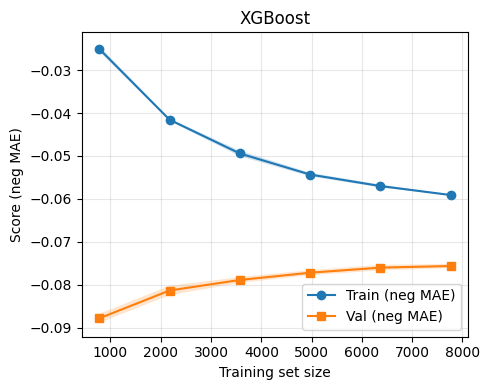

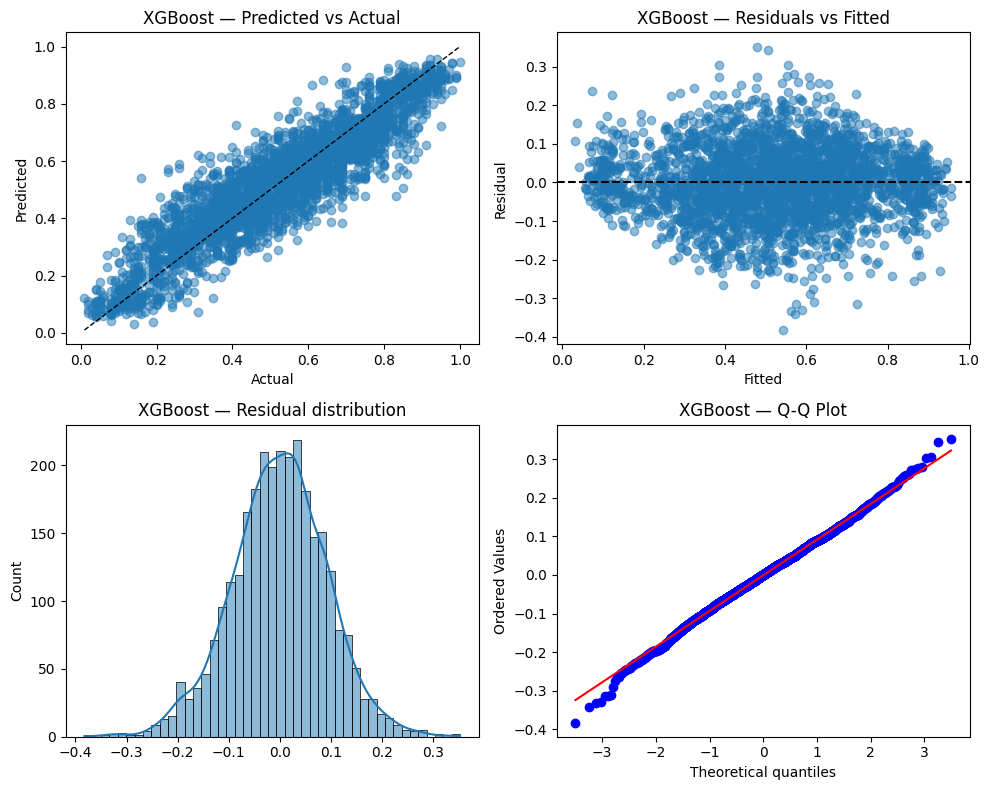

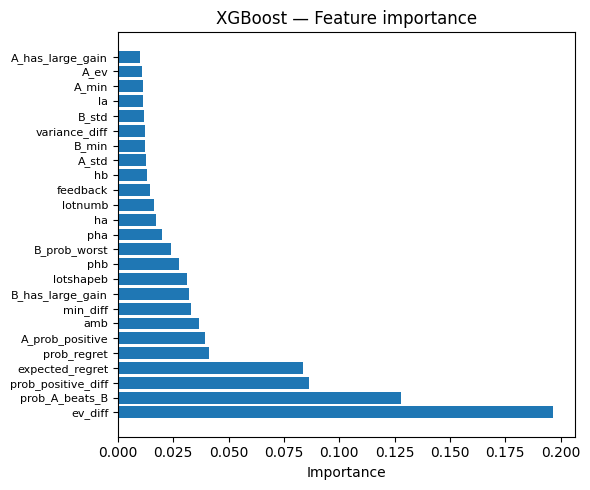

100%|===================| 199/200 [00:14<00:00]       

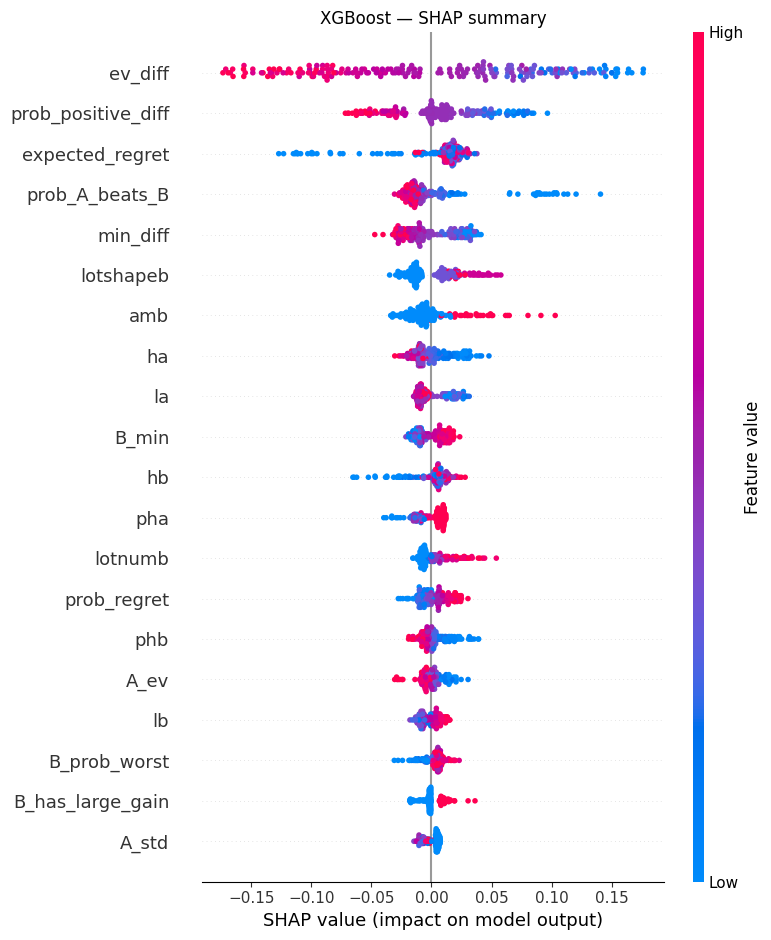

In [36]:
xgb = XGBRegressor(
    random_state=42,
    n_jobs=-1,
    tree_method="hist"   # much faster on CPU
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "n_estimators": ("int", 200, 1500, False, 50),
    "learning_rate": ("float", 1e-3, 3e-1, True),
    "max_depth": ("int", 2, 10, False, 1),

    # regularization / robustness (big wins)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),
    "min_child_weight": ("float", 1.0, 20.0, True),
    "reg_alpha": ("float", 1e-8, 1.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful
    "gamma": ("float", 1e-8, 5.0, True),
}

result8 = run_experiment(
    xgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,   # optional speed-up; remove if you want full data tuning
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="XGBoost",
)

pipeline = result8.best_estimator
pred8 = result8.predictions
best_params8 = result8.best_params
metrics8 = result8.metrics


In [37]:

print("**XGBoost results**")
print("Best hyperparameters:", result8.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics8["MAE"], metrics8["RMSE"], metrics8["MSE"], metrics8["R2"]))


**XGBoost results**
Best hyperparameters: {'reg__n_estimators': 1450, 'reg__learning_rate': 0.011934245506763985, 'reg__max_depth': 5, 'reg__subsample': 0.6895639425779669, 'reg__colsample_bytree': 0.7824447269164796, 'reg__min_child_weight': 5.600832675230202, 'reg__reg_alpha': 8.729193460229443e-07, 'reg__reg_lambda': 6.115483046728381, 'reg__gamma': 0.0001475204551925676}
Test metrics: MAE = 0.07264, RMSE = 0.09253, MSE = 0.00856, R2 = 0.82522


### LightGBM

We fit a LightGBM regressor with Optuna tuning. LightGBM often trains quickly and can perform well on tabular data.

In [ ]:
lgb = LGBMRegressor(
    random_state=42,
    n_jobs=-1
)

# Optuna search space (compatible with your run_experiment(..., search_engine="optuna"))
params_optuna = {
    # core
    "learning_rate": ("float", 1e-3, 2e-1, True),
    "n_estimators": ("int", 200, 4000, False, 100),

    # tree shape / capacity
    "num_leaves": ("int", 16, 256, True),        # log-ish effect
    "max_depth": ("int", -1, 16, False, 1),      # -1 means no limit
    "min_child_samples": ("int", 5, 120, False, 1),

    # sampling (regularization)
    "subsample": ("float", 0.6, 1.0, False),
    "colsample_bytree": ("float", 0.6, 1.0, False),

    # regularization
    "reg_alpha": ("float", 1e-8, 10.0, True),
    "reg_lambda": ("float", 1e-3, 100.0, True),

    # optional but often helpful on noisy data
    "min_split_gain": ("float", 1e-8, 1.0, True),
}

result9 = run_experiment(
    lgb,
    X,
    y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=40,
    verbose=1,
    sample_size=0.5,  # optional speed-up; remove if you want full-data tuning
    plots=["learning_curve", "diagnostics_4panel", "feature_importance", "shap"],
    model_name="LightGBM",
)

pipeline = result9.best_estimator
pred9 = result9.predictions
best_params9 = result9.best_params
metrics9 = result9.metrics


In [ ]:
# LightGBM results: hyperparameters and test metrics
print("**LightGBM results**")
print("Best hyperparameters:", result9.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics9["MAE"], metrics9["RMSE"], metrics9["MSE"], metrics9["R2"]))


**Comment:** LightGBM’s leaf-wise growth can capture fine structure quickly. Compare its test MAE with XGBoost and with the second stacking ensemble that uses both tree-based and linear models.

### Second stacking (XGB + LightGBM + Ridge)

A second stacking ensemble using the best-tuned XGBoost, LightGBM, and Ridge as base learners. The meta-learner is tuned (e.g. via Optuna) on the stacking pipeline.

In [ ]:
estimators = [
    ("xgb", result8.best_estimator.named_steps["reg"]),
    ("lgb", result9.best_estimator.named_steps["reg"]),
]

stack = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(random_state=42),
    cv=3,          # tune with 3 for speed; set to 5 for final refit
    n_jobs=-1
)

params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e2, True),
    "final_estimator__fit_intercept": ("categorical", [True, False]),
    "passthrough": ("categorical", [False, True]),
}

result10 = run_experiment(
    stack,
    X, y,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    model_name="Stacking (XGB+LGBM+Ridge)",
)

pipeline = result10.best_estimator
pred10 = result10.predictions
best_params10 = result10.best_params
metrics10 = result10.metrics


In [ ]:
# Second stacking (XGB+LGBM+Ridge) results: hyperparameters and test metrics
print("**Second stacking (XGB+LGBM+Ridge) results**")
print("Best hyperparameters:", result10.best_params)
print("Test metrics: MAE = {:.5f}, RMSE = {:.5f}, MSE = {:.5f}, R2 = {:.5f}".format(
    metrics10["MAE"], metrics10["RMSE"], metrics10["MSE"], metrics10["R2"]))
print("Compare MAE with the first stacking and single models.")


**Comment:** This stacking uses XGBoost, LightGBM, and Ridge as base learners. The meta-learner’s weights reflect how much each base model contributes; compare this ensemble’s MAE with the first stacking and with single models in the summary below.

In [ ]:
rows = []

if "metrics1" in globals():
    rows.append({"model": "model1_ridge", "MAE": metrics1["MAE"]})
if "metrics2" in globals():
    rows.append({"model": "model2_rf", "MAE": metrics2["MAE"]})
if "metrics3" in globals():
    rows.append({"model": "model3_svr", "MAE": metrics3["MAE"]})
if "metrics4" in globals():
    rows.append({"model": "model4_gbr", "MAE": metrics4["MAE"]})
if "metrics7" in globals():
    rows.append({"model": "model7_stack", "MAE": metrics7["MAE"]})
if "metrics8" in globals():
    rows.append({"model": "model8_xgb", "MAE": metrics8["MAE"]})
if "metrics9" in globals():
    rows.append({"model": "model9_lgbm", "MAE": metrics9["MAE"]})
if "metrics10" in globals():
    rows.append({"model": "model10_stack2", "MAE": metrics10["MAE"]})

if not rows:
    print("No metrics objects (metrics1, metrics2, ...) found. Run the model cells first.")
else:
    mae_df = pd.DataFrame(rows)
    mae_df = mae_df.sort_values("MAE").reset_index(drop=True)

    print("MAE per non-NN model (sorted, lower is better):")
    display(mae_df.style.format({"MAE": "{:.6f}"}))

### Correlation of model errors

We compute the correlation matrix of test-set errors (y_test − prediction) across the non-NN models. High correlation suggests models make similar mistakes; low correlation can indicate complementary predictors.

In [ ]:
#Error correlation between models using stored errors
error_dict = {}

if "result1" in globals():
    error_dict["model1_ridge"] = result1.errors
if "result2" in globals():
    error_dict["model2_rf"] = result2.errors
if "result3" in globals():
    error_dict["model3_svr"] = result3.errors
if "result4" in globals():
    error_dict["model4_gbr"] = result4.errors
if "result7" in globals():
    error_dict["model7_stack"] = result7.errors
if "result8" in globals():
    error_dict["model8_xgb"] = result8.errors
if "result9" in globals():
    error_dict["model9_lgbm"] = result9.errors
if "result10" in globals():
    error_dict["model10_stack2"] = result10.errors

if not error_dict:
    print("No non-NN result objects with errors found (result1, result2, ...). Run the model cells first.")
else:
    errors_df = pd.DataFrame(error_dict)

    print("First 5 rows of model errors (y_test - y_pred):")
    display(errors_df.head())

    corr_errors = errors_df.corr()
    print("\nCorrelation matrix of model errors:")
    display(corr_errors)

    plt.figure(figsize=(6, 4))
    sns.heatmap(corr_errors, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
    plt.title("Correlation of errors between models (non-NN)")
    plt.tight_layout()
    plt.show()

### Final stacking with ElasticNet meta-learner

We build a stacking model using the best GBR, Ridge, and SVR pipelines as base estimators and an ElasticNet regressor as the meta-learner. The meta-learner’s hyperparameters (alpha, l1_ratio) are tuned with Optuna. Final performance is evaluated on the held-out test set.

In [ ]:
# 0) Same split policy as run_experiment
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 1) Define base estimators with names
# Using the FULL pipelines (NOT named_steps["reg"])
estimators = [
    ('gbstack', result10.best_estimator.named_steps["reg"]),
    ('ridge', result1.best_estimator.named_steps["reg"]),
    ('svr', result3.best_estimator.named_steps["reg"]),
]

# 2) Create StackingRegressor with ElasticNet as meta-learner
stacking_reg = StackingRegressor(
    estimators=estimators,
    final_estimator=ElasticNet(random_state=42, max_iter=10_000),
    cv=3,  # 3-fold CV for generating meta-features
    n_jobs=-1
)


# Create param grid with 'final_estimator__' prefix
params_optuna = {
    "final_estimator__alpha": ("float", 1e-6, 1e1, True),
    "final_estimator__l1_ratio": ("float", 0.0, 1.0),
}

result_stack = run_experiment(
    stacking_reg,
    X_train, y_train,
    params=params_optuna,
    search_engine="optuna",
    cv_folds=3,
    n_trials=25,
    verbose=1,
    plots=["learning_curve", "diagnostics_4panel", "feature_importance"],
    run_full_pipeline=True  # The stacking regressor handles everything
)

best_stacking = result_stack.best_estimator

# 4) Final evaluation on the held-out test split
pred_test = best_stacking.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
rmse = float(np.sqrt(mean_squared_error(y_test, pred_test)))
mse = mean_squared_error(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

print({"MAE": mae, "RMSE": rmse, "MSE": mse, "R2": r2})

**Comment:** The ElasticNet meta-learner blends L1 and L2 to combine GBR, Ridge, and SVR predictions. The printed test metrics show whether this final stacking improves over the best single model and over the other stacking; use the MAE summary table for a direct comparison.

### Model comparison (test metrics)

Summary of test-set metrics for each ML model below. Use this table to compare MAE, RMSE, MSE, and R² across models before moving on to the neural network.

In [ ]:
# Build a single table: model name and each metric (MAE, RMSE, MSE, R2)
model_metrics = []
if "metrics1" in globals():
    model_metrics.append({"Model": "Ridge", **metrics1})
if "metrics2" in globals():
    model_metrics.append({"Model": "Random Forest", **metrics2})
if "metrics3" in globals():
    model_metrics.append({"Model": "SVR", **metrics3})
if "metrics4" in globals():
    model_metrics.append({"Model": "Gradient Boosting", **metrics4})
if "metrics7" in globals():
    model_metrics.append({"Model": "Stack (RF+SVR+GBR)", **metrics7})
if "metrics8" in globals():
    model_metrics.append({"Model": "XGBoost", **metrics8})
if "metrics9" in globals():
    model_metrics.append({"Model": "LightGBM", **metrics9})
if "metrics10" in globals():
    model_metrics.append({"Model": "Final stack (XGB+LGB+ElasticNet)", **metrics10})

if model_metrics:
    df_metrics = pd.DataFrame(model_metrics)
    # Reorder columns: Model first, then MAE, RMSE, MSE, R2
    df_metrics = df_metrics[["Model", "MAE", "RMSE", "MSE", "R2"]]
    df_metrics = df_metrics.rename(columns={"R2": "R²"}).round(6)
    display(df_metrics)
else:
    print("Run the model cells above to populate the metrics table.")

### Neural Network

We train a feedforward network (`Choices13kNet`) on the scaled features, with optional Optuna tuning of architecture and training hyperparameters. Validation loss is monitored for early stopping; the best model is saved and evaluated on the test set.

**Data preparation.** We keep only numeric (and boolean) columns from the engineered features, split into 80% train / 20% test, scale with `StandardScaler`, and convert to PyTorch tensors and a DataLoader for training.

In [40]:
X = X.select_dtypes(include=[np.number, "bool"])

In [41]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [42]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [43]:
X_tr_torch = torch.FloatTensor(X_train_scaled)
y_tr_torch = torch.FloatTensor(y_train.values).unsqueeze(1)
X_te_torch = torch.FloatTensor(X_test_scaled)
y_te_torch = torch.FloatTensor(y_test.values).unsqueeze(1)

In [44]:
train_dataset = TensorDataset(X_tr_torch, y_tr_torch)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)

**Model.** `Choices13kNet` is a feedforward network with configurable hidden layer sizes and dropout. The final layer outputs a single value in [0, 1] via Sigmoid for the choice rate.

In [45]:
class Choices13kNet(nn.Module):
    def __init__(self, input_dim, hidden=(128, 64, 32), dropout=0.0):
        super().__init__()
        layers = []
        dims = [input_dim] + list(hidden)
        for i in range(len(dims) - 1):
            layers.append(nn.Linear(dims[i], dims[i + 1]))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
        layers.append(nn.Linear(dims[-1], 1))
        layers.append(nn.Sigmoid())
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

**Training setup.** We set input dimension from the data, instantiate the model with default architecture, and define MSE loss, AdamW optimizer, and a ReduceLROnPlateau scheduler.

In [46]:
input_dim = X_train.shape[1]
model = Choices13kNet(input_dim)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001, weight_decay=0.01)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

**Train/validation split.** We hold out 20% of the training data for validation. This split is used for early stopping and for Optuna; the test set remains untouched until final evaluation.

In [47]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(42)

# Train/val split from training data (don't use test set for tuning)
n_train = len(X_tr_torch)
idx = torch.randperm(n_train, generator=torch.Generator().manual_seed(42))
n_val = int(0.2 * n_train)
val_idx, train_idx = idx[:n_val], idx[n_val:]

X_val_torch = X_tr_torch[val_idx]
y_val_torch = y_tr_torch[val_idx]
X_opt_torch = X_tr_torch[train_idx]
y_opt_torch = y_tr_torch[train_idx]


**Training helper.** `train_nn_one_run` runs one training loop with validation MAE monitoring and early stopping. It returns best validation MAE, best epoch, and history for plotting.

In [48]:
def _mae_torch(pred: torch.Tensor, y: torch.Tensor) -> float:
    return torch.mean(torch.abs(pred - y)).item()

@torch.no_grad()
def eval_epoch(model, X, y, criterion):
    model.eval()
    Xd, yd = X.to(device), y.to(device)
    pred = model(Xd)
    loss = criterion(pred, yd).item()
    mae = _mae_torch(pred, yd)
    return loss, mae

def train_nn_one_run(
    model,
    train_loader,
    X_val,
    y_val,
    criterion,
    optimizer,
    scheduler=None,
    max_epochs=300,
    patience=40,
    *,
    verbose: bool = False,
    log_every: int = 1,
):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_mae": [],
        "val_mae": [],
        "lr": [],
    }

    best_val_mae = float("inf")
    best_epoch = -1
    best_state = None
    patience_counter = 0

    for epoch in range(max_epochs):
        model.train()
        running_loss = 0.0
        running_mae = 0.0

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad(set_to_none=True)
            pred = model(batch_x)
            loss = criterion(pred, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item()
            running_mae += _mae_torch(pred.detach(), batch_y)

        train_loss = running_loss / len(train_loader)
        train_mae = running_mae / len(train_loader)

        val_loss, val_mae = eval_epoch(model, X_val, y_val, criterion)

        if scheduler is not None:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_mae"].append(train_mae)
        history["val_mae"].append(val_mae)
        history["lr"].append(optimizer.param_groups[0]["lr"])

        is_best = False
        if val_mae < best_val_mae - 1e-12:
            best_val_mae = val_mae
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
            is_best = True
        else:
            patience_counter += 1

        # ---- logging ----
        if verbose and (epoch % log_every == 0 or epoch == max_epochs - 1):
            tag = " ★" if is_best else ""
            print(
                f"[epoch {epoch:03d}] "
                f"train MAE={train_mae:.5f} | "
                f"val MAE={val_mae:.5f} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
                f"{tag}"
            )

        if patience_counter >= patience:
            if verbose:
                print(f"Early stopping at epoch {epoch} (best={best_epoch})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return {
        "best_val_mae": best_val_mae,
        "best_epoch": best_epoch,
        "history": history,
    }


**Hyperparameter tuning.** Optuna minimizes mean validation MAE over 5-fold cross-validation, searching over learning rate, weight decay, batch size, dropout, and hidden layer sizes. The best trial’s parameters are used for the final refit.

In [50]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-1, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256])
    dropout = trial.suggest_float("dropout", 0.0, 0.4)
    h1 = trial.suggest_categorical("h1", [32, 64, 128, 256])
    h2 = trial.suggest_categorical("h2", [32, 64, 128])
    h3 = trial.suggest_categorical("h3", [16, 32, 64])
    hidden = (h1, h2, h3)

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    maes = []

    X = X_tr_torch
    y = y_tr_torch

    for tr_idx, va_idx in kf.split(np.arange(len(X))):
        X_tr, y_tr = X[tr_idx], y[tr_idx]
        X_va, y_va = X[va_idx], y[va_idx]

        model = Choices13kNet(input_dim, hidden=hidden, dropout=dropout).to(device)
        opt = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=20, factor=0.5)
        crit = nn.MSELoss()

        loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=batch_size, shuffle=True)

        out = train_nn_one_run(model, loader, X_va, y_va, crit, opt, sch, max_epochs=300, patience=40, verbose = True, log_every=50)
        _, va_mae = eval_epoch(model, X_va, y_va, crit)
        maes.append(va_mae)

    return float(np.mean(maes))


optuna.logging.set_verbosity(optuna.logging.WARNING)
study_nn = optuna.create_study(direction="minimize")
study_nn.optimize(objective, n_trials=25, show_progress_bar=True)

print("Best params:", study_nn.best_params, "| Best val MAE:", study_nn.best_value)


  0%|          | 0/25 [00:00<?, ?it/s]

[epoch 000] train MAE=0.12915 | val MAE=0.09627 | lr=1.04e-03 ★
[epoch 001] train MAE=0.10569 | val MAE=0.09288 | lr=1.04e-03 ★
[epoch 002] train MAE=0.10045 | val MAE=0.09292 | lr=1.04e-03
[epoch 003] train MAE=0.09850 | val MAE=0.09074 | lr=1.04e-03 ★
[epoch 004] train MAE=0.09697 | val MAE=0.08960 | lr=1.04e-03 ★
[epoch 005] train MAE=0.09648 | val MAE=0.08886 | lr=1.04e-03 ★
[epoch 006] train MAE=0.09522 | val MAE=0.08942 | lr=1.04e-03
[epoch 007] train MAE=0.09468 | val MAE=0.08832 | lr=1.04e-03 ★
[epoch 008] train MAE=0.09372 | val MAE=0.08747 | lr=1.04e-03 ★
[epoch 009] train MAE=0.09406 | val MAE=0.09054 | lr=1.04e-03
[epoch 010] train MAE=0.09363 | val MAE=0.08839 | lr=1.04e-03
[epoch 011] train MAE=0.09293 | val MAE=0.08617 | lr=1.04e-03 ★
[epoch 012] train MAE=0.09287 | val MAE=0.08820 | lr=1.04e-03
[epoch 013] train MAE=0.09172 | val MAE=0.08796 | lr=1.04e-03
[epoch 014] train MAE=0.09187 | val MAE=0.08852 | lr=1.04e-03
[epoch 015] train MAE=0.09159 | val MAE=0.08905 | lr=1

KeyboardInterrupt: 

**Refit and evaluate.** The best Optuna configuration is trained on the full training set. We plot train/validation MAE vs epoch, restore the best-epoch weights, compute test MAE, and save the model and metadata.

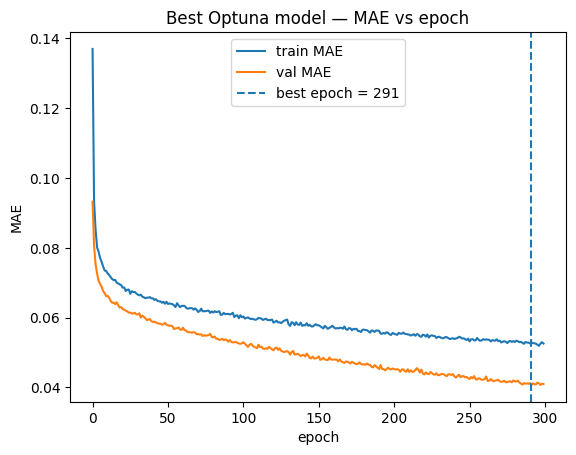

Refit done. Best epoch: 291 | best val MAE: 0.040736 | TEST MAE: 0.062618


In [ ]:
bp = study_nn.best_params
hidden_best = (bp["h1"], bp["h2"], bp["h3"])

model = Choices13kNet(input_dim, hidden=hidden_best, dropout=bp["dropout"]).to(device)
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=bp["lr"], weight_decay=bp["weight_decay"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)

train_loader_full = DataLoader(
    TensorDataset(X_tr_torch, y_tr_torch),
    batch_size=bp["batch_size"],
    shuffle=True,
)

out = train_nn_one_run(
    model=model,
    train_loader=train_loader_full,
    X_val=X_val_torch,
    y_val=y_val_torch,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    max_epochs=300,
    patience=40,
    verbose=True
)

history = out["history"]
best_epoch = out["best_epoch"]
best_val_mae = out["best_val_mae"]

# Plot MAE map (epoch vs MAE) for train/val
epochs = np.arange(len(history["train_mae"]))

plt.figure()
plt.plot(epochs, history["train_mae"], label="train MAE")
plt.plot(epochs, history["val_mae"], label="val MAE")
plt.axvline(best_epoch, linestyle="--", label=f"best epoch = {best_epoch}")
plt.xlabel("epoch")
plt.ylabel("MAE")
plt.legend()
plt.title("Best Optuna model — MAE vs epoch")
plt.show()

@torch.no_grad()
def predict(model, X):
    model.eval()
    return model(X.to(device)).detach().cpu().numpy().reshape(-1)

test_pred = predict(model, X_te_torch)
test_mae = mean_absolute_error(y_te_torch.detach().cpu().numpy().reshape(-1), test_pred)

torch.save(
    {
        "state_dict": model.state_dict(),  # already best epoch
        "best_params": bp,
        "best_epoch": best_epoch,
        "best_val_mae": best_val_mae,
        "history": history,
    },
    "best_choices13k_optuna_refit.pt",
)

print(f"Refit done. Best epoch: {best_epoch} | best val MAE: {best_val_mae:.6f} | TEST MAE: {test_mae:.6f}")


## Lottery-based neural network (LotteryEncoder + ChoicesRegressor)

We train a second neural network that operates directly on the raw lottery structure: each option is a list of (probability, outcome) pairs. The model encodes lottery A and lottery B with a shared encoder (token MLP + attention and mean/max pooling), then compares the two embeddings to predict the choice rate for B. This uses the same train/validation/test split as the rest of the notebook.

**Lottery data.** We parse lotteries A and B and the target from `df_full`, pad to a common length with masks, and apply the same 80/20 train–test then 80/20 train–val split. Engineered features X are aligned to these splits for the hybrid model.

In [ ]:
def parse_lottery(cell):
    """Parse a lottery cell  to list of [p, x]."""
    L = cell
    return [[float(px[0]), float(px[1])] for px in L]

A_list = [parse_lottery(v) for v in df_full["A"].tolist()]
B_list = [parse_lottery(v) for v in df_full["B"].tolist()]
y_lottery = df_full["brate"].to_numpy(dtype=np.float32)

max_na = max(len(a) for a in A_list)
max_nb = max(len(b) for b in B_list)

def to_tensor(lottery_list, max_len):
    """Pad lotteries to (N, max_len, 2) and create mask (N, max_len)."""
    N = len(lottery_list)
    L = np.zeros((N, max_len, 2), dtype=np.float32)
    mask = np.zeros((N, max_len), dtype=bool)
    for i, lot in enumerate(lottery_list):
        n = len(lot)
        L[i, :n] = lot
        mask[i, :n] = True
    return torch.from_numpy(L), torch.from_numpy(mask)

A_tensor, maskA = to_tensor(A_list, max_na)
B_tensor, maskB = to_tensor(B_list, max_nb)
y_tensor = torch.from_numpy(y_lottery).float()

# Same split as rest of notebook: 80% train, 20% test
idx = np.arange(len(y_lottery))
np.random.seed(42)
np.random.shuffle(idx)
n_test = int(0.2 * len(idx))
test_idx = idx[:n_test]
train_idx = idx[n_test:]

A_train, A_test = A_tensor[train_idx], A_tensor[test_idx]
B_train, B_test = B_tensor[train_idx], B_tensor[test_idx]
maskA_train, maskA_test = maskA[train_idx], maskA[test_idx]
maskB_train, maskB_test = maskB[train_idx], maskB[test_idx]
y_train_lot, y_test_lot = y_tensor[train_idx], y_tensor[test_idx]

# Validation split from training (20% of train)
n_val = int(0.2 * len(train_idx))
perm = np.random.RandomState(42).permutation(len(train_idx))
val_idx, tr_idx = perm[:n_val], perm[n_val:]
A_tr = A_train[tr_idx]; A_val = A_train[val_idx]
B_tr = B_train[tr_idx]; B_val = B_train[val_idx]
maskA_tr = maskA_train[tr_idx]; maskA_val = maskA_train[val_idx]
maskB_tr = maskB_train[tr_idx]; maskB_val = maskB_train[val_idx]
y_tr_lot = y_train_lot[tr_idx]; y_val_lot = y_train_lot[val_idx]

# Engineered features X (same row order as df_full; X from feature-engineering section)
X_all = np.asarray(X.values, dtype=np.float32)
X_tr_lot = torch.from_numpy(X_all[train_idx][tr_idx]).float()
X_val_lot = torch.from_numpy(X_all[train_idx][val_idx]).float()
X_test_lot = torch.from_numpy(X_all[test_idx]).float()

print(f"Train {A_tr.shape[0]}, Val {A_val.shape[0]}, Test {A_test.shape[0]}")
print(f"Max outcomes A: {max_na}, B: {max_nb}")
print(f"Engineered X: train {X_tr_lot.shape}, val {X_val_lot.shape}, test {X_test_lot.shape}")

**Lottery model.** `LotteryEncoder` maps each lottery (list of (p, x) outcomes) to a fixed-size vector via token-level features, an MLP, and attention plus mean/max pooling. `ChoicesRegressor` concatenates the encodings of A and B with the engineered feature matrix X and predicts brate with a small head.

In [ ]:
class LotteryEncoder(nn.Module):
    """
    L: (B,N,2) with [p,x] per outcome.
    Produces a fixed embedding (B,d_model) using engineered features + attention/mean/max pooling.
    """
    def __init__(self, d_model=64, d_hidden=128, dropout=0.1):
        super().__init__()
        self.token_mlp = nn.Sequential(
            nn.Linear(8, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
            nn.ReLU(),
        )
        self.attn = nn.Sequential(
            nn.Linear(d_model, d_hidden),
            nn.Tanh(),
            nn.Linear(d_hidden, 1),
        )
        self.out = nn.Sequential(
            nn.Linear(3 * d_model, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, d_model),
        )

    def forward(self, L, mask=None):
        p = L[..., 0].clamp_min(1e-12)
        x = L[..., 1]

        # normalize probs within each lottery
        if mask is not None:
            p = p * mask.to(L.dtype)
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)
        else:
            p = p / p.sum(dim=1, keepdim=True).clamp_min(1e-12)

        logp = torch.log(p.clamp_min(1e-12))
        feats = torch.stack(
            [x, x.abs(), x * x, torch.sign(x), p, logp, p * x, p * x.abs()],
            dim=-1,
        )

        h = self.token_mlp(feats)  # (B,N,d)

        scores = self.attn(h).squeeze(-1)  # (B,N)
        if mask is not None:
            scores = scores.masked_fill(~mask, float("-inf"))
        w = F.softmax(scores, dim=1).unsqueeze(-1)  # (B,N,1)

        h_attn = (w * h).sum(dim=1)  # (B,d)

        if mask is not None:
            denom = mask.sum(dim=1, keepdim=True).clamp_min(1).to(L.dtype)
            h_mean = (h * mask.unsqueeze(-1).to(L.dtype)).sum(dim=1) / denom
            h_max = h.masked_fill(~mask.unsqueeze(-1), float("-inf")).max(dim=1).values
            h_max = torch.where(torch.isfinite(h_max), h_max, torch.zeros_like(h_max))
        else:
            h_mean = h.mean(dim=1)
            h_max = h.max(dim=1).values

        z = torch.cat([h_attn, h_mean, h_max], dim=-1)  # (B,3d)
        return self.out(z)  # (B,d)


class ChoicesRegressor(nn.Module):
    """
    Predicts brate from encoded (A,B) lotteries and engineered features X.
    """
    def __init__(self, d_model=64, d_hidden=128, dropout=0.1, input_dim_engineered=0):
        super().__init__()
        self.enc = LotteryEncoder(d_model=d_model, d_hidden=d_hidden, dropout=dropout)
        self.head = nn.Sequential(
            nn.Linear(4 * d_model + input_dim_engineered, d_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_hidden, 1),
            nn.Sigmoid(),
        )

    def forward(self, A, B, maskA=None, maskB=None, X_engineered=None):
        zA = self.enc(A, maskA)
        zB = self.enc(B, maskB)
        lottery_feats = torch.cat([zA, zB, zA - zB, zA * zB], dim=-1)
        if X_engineered is not None:
            feats = torch.cat([lottery_feats, X_engineered], dim=-1)
        else:
            feats = lottery_feats
        return self.head(feats).squeeze(-1)

**Training and evaluation.** We define a `LotteryDataset` and DataLoader that yield (A, B, masks, y, X_engineered). The model is trained with MSE loss and early stopping on validation MAE; the best checkpoint is restored and evaluated on the test set.

In [ ]:
class LotteryDataset(torch.utils.data.Dataset):
    def __init__(self, A, B, maskA, maskB, y, X_engineered=None):
        self.A, self.B = A, B
        self.maskA, self.maskB = maskA, maskB
        self.y = y
        self.X_engineered = X_engineered

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        if self.X_engineered is not None:
            return self.A[i], self.B[i], self.maskA[i], self.maskB[i], self.y[i], self.X_engineered[i]
        return self.A[i], self.B[i], self.maskA[i], self.maskB[i], self.y[i], None

def collate_lottery(batch):
    A = torch.stack([b[0] for b in batch])
    B = torch.stack([b[1] for b in batch])
    maskA = torch.stack([b[2] for b in batch])
    maskB = torch.stack([b[3] for b in batch])
    y = torch.stack([b[4] for b in batch])
    X_engineered = torch.stack([b[5] for b in batch]) if batch[0][5] is not None else None
    return A, B, maskA, maskB, y, X_engineered

device_lot = torch.device("cuda" if torch.cuda.is_available() else "cpu")
input_dim_engineered = X_tr_lot.shape[1]

train_ds = LotteryDataset(A_tr, B_tr, maskA_tr, maskB_tr, y_tr_lot, X_tr_lot)
train_loader_lot = DataLoader(train_ds, batch_size=64, shuffle=True, collate_fn=collate_lottery)

model_lot = ChoicesRegressor(d_model=64, d_hidden=128, dropout=0.1, input_dim_engineered=input_dim_engineered).to(device_lot)
opt_lot = torch.optim.AdamW(model_lot.parameters(), lr=1e-3, weight_decay=1e-5)
criterion_lot = nn.MSELoss()

n_epochs = 150
best_val_mae_lot = float("inf")
best_state = None
patience_counter = 0
patience = 20

for epoch in range(n_epochs):
    model_lot.train()
    for A, B, mA, mB, y, X_eng in train_loader_lot:
        A, B = A.to(device_lot), B.to(device_lot)
        mA, mB = mA.to(device_lot), mB.to(device_lot)
        y = y.to(device_lot)
        if X_eng is not None:
            X_eng = X_eng.to(device_lot)
        opt_lot.zero_grad()
        pred = model_lot(A, B, mA, mB, X_engineered=X_eng)
        loss = criterion_lot(pred, y)
        loss.backward()
        opt_lot.step()

    model_lot.eval()
    with torch.no_grad():
        pred_val = model_lot(A_val.to(device_lot), B_val.to(device_lot),
                             maskA_val.to(device_lot), maskB_val.to(device_lot),
                             X_engineered=X_val_lot.to(device_lot))
        val_mae_lot = torch.mean(torch.abs(pred_val - y_val_lot.to(device_lot))).item()

    if val_mae_lot < best_val_mae_lot:
        best_val_mae_lot = val_mae_lot
        best_state = {k: v.cpu().clone() for k, v in model_lot.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 25 == 0:
        print(f"Epoch {epoch+1}  val MAE: {val_mae_lot:.5f}  best: {best_val_mae_lot:.5f}")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

if best_state is not None:
    model_lot.load_state_dict(best_state)

model_lot.eval()
with torch.no_grad():
    pred_test_lot = model_lot(A_test.to(device_lot), B_test.to(device_lot),
                              maskA_test.to(device_lot), maskB_test.to(device_lot),
                              X_engineered=X_test_lot.to(device_lot))
test_mae_lottery = torch.mean(torch.abs(pred_test_lot - y_test_lot.to(device_lot))).item()
print(f"\nLottery network (encoded A,B + X) — Test MAE: {test_mae_lottery:.6f}")